# Interactive Tutorial for the HWO UV Instrument (UVI) — UV IFS Mode

This notebook explores the **Habitable Worlds Observatory (HWO) UV Integral Field Spectrograph (UV IFS)** exposure-time calculation using the current EAC5 hardware model in `hwome`/`syotools`.

The interactive dashboard combines the built-in `syotools` spectral library with selected **theoretical TLUSTY/NLTE OB-star atmosphere models** from the STScI `nlte-obgrid` HLSP. The TLUSTY spectra are downloaded from MAST, registered as custom spectral templates, normalized to a user-selected **GALEX FUV AB magnitude**, and passed through the UV-IFS ETC calculation to examine the resulting source SED and signal-to-noise ratio.

This is a **work-in-progress ETC validation/tutorial notebook**. 

AI was used to aid in the development of this Notebook.


## 1. Requirements and installation

This notebook uses the HWO exposure-time-calculator development stack together with standard astronomical Python packages. Before running the notebook, make sure the required software and model-data repositories are available in your Python environment.

### 1.1 Python and Jupyter environment

A recent Python 3 environment with Jupyter Notebook or JupyterLab is recommended. The notebook imports the following general-purpose packages:

- `numpy`
- `astropy`
- `synphot`
- `stsynphot`
- `ipywidgets`
- `requests`
- `matplotlib`

It also requires the HWO-specific packages and data used by the current ETC development environment:

- `syotools`
- `hwome`
- the HWO Science–Engineering Interface data (`hwo_sci_eng` / `Sci-Eng-Interface`)
- the local `hwome_data` repository containing the EAC5 observatory model and associated throughput/coating files

The exact installation method for the HWO development packages may depend on the version of the HWO ETC environment being used. This notebook assumes that `syotools`, `hwome`, and the Science–Engineering Interface have already been installed or made available to the active Python environment.

### 1.2 Network access

Internet access is required when the notebook downloads the selected TLUSTY/NLTE stellar-atmosphere files from MAST. The interactive plots also load Chart.js, Hammer.js, and `chartjs-plugin-zoom` from a public CDN when the dashboard is rendered.

### 1.3 Configure the local `hwome_data` path

<div style="
    background-color:#fde8e8;
    border:2px solid #c62828;
    border-left:8px solid #c62828;
    padding:14px 16px;
    margin:12px 0 16px 0;
    color:#7f0000;
    font-weight:600;
">
<strong>USER ACTION REQUIRED:</strong><br>
Before running the setup cell below, make sure <code>HWOME_DATA_PATH</code> points to your local
<code>hwome_data</code> repository. If the environment variable is not already defined, edit the
placeholder <code>/path/to/hwome_data</code> in the setup cell and replace it with the correct path
on your machine.
</div>

The setup cell first checks whether `HWOME_DATA_PATH` is already defined in the user's environment. If it is not, it falls back to an editable placeholder:

```python
HWOME = os.environ.get("HWOME_DATA_PATH")

if HWOME is None:
    HWOME = "/path/to/hwome_data"   # USER: change this
```

Alternatively, users can define the path before starting Jupyter, for example:

```bash
export HWOME_DATA_PATH=/absolute/path/to/hwome_data
```

Using the environment variable is preferable when the notebook will be shared among multiple users because it avoids storing machine-specific directory paths in the notebook itself.


## 2. Set up the HWO ETC environment

The first two cells configure the local `syotools`, `stsynphot`, and HWO model-data paths and import the packages used throughout the notebook. These settings must be established before constructing the telescope and instrument models in a fresh kernel.

The setup also includes local workarounds for the current development versions of the HWO ETC software stack. The notebook leaves those workarounds explicit so that the calculation remains reproducible while the underlying packages continue to evolve.


### 2.1 Configure `syotools`, `stsynphot`, and HWO data paths


In [1]:
import os, glob, logging
logging.disable(logging.WARNING)  # HWOME/synphot emit benign load-time warnings

import syotools
_syo = os.path.dirname(syotools.__file__)
_correct_data_dir = os.path.join(_syo, "reference_data")
_correct_cdbs = os.path.join(_syo, "reference_data", "pysynphot_data")

os.environ.setdefault("SYOTOOLS_DATA_DIR", _correct_data_dir)

# Validate, don't just fill in if unset -- a stale PYSYN_CDBS inherited from a shell
# rc file (e.g. the STScI-internal /grp/hst/cdbs path) would already be "set" and
# setdefault would silently keep it even though it's wrong for this install.
_current_cdbs = os.environ.get("PYSYN_CDBS")
if not _current_cdbs or not os.path.isdir(os.path.join(_current_cdbs, "mtab")):
    os.environ["PYSYN_CDBS"] = _correct_cdbs

import stsynphot
stsynphot.config.conf.rootdir = _correct_cdbs  # bypasses stsynphot's own import-time env-var caching

if not (os.environ.get("SCI_ENG_DIR") and
        os.path.isdir(os.path.join(os.environ.get("SCI_ENG_DIR", ""), "obs_config"))):
    for c in [os.path.expanduser("~/Sci-Eng-Interface/hwo_sci_eng"),
              "/Sci-Eng-Interface/hwo_sci_eng",
              os.path.join(os.getcwd(), "Sci-Eng-Interface", "hwo_sci_eng")]:
        if os.path.isdir(os.path.join(c, "obs_config", "Tel")):
            os.environ["SCI_ENG_DIR"] = c
            break
    else:
        try:
            import hwo_sci_eng
            for p in getattr(hwo_sci_eng, "__path__", []):
                if os.path.isdir(os.path.join(p, "obs_config", "Tel")):
                    os.environ["SCI_ENG_DIR"] = p
                    break
        except Exception:
            pass

HWOME = os.environ.get("HWOME_DATA_PATH")

if HWOME is None:
    HWOME =  "/Users/lubeda/astronomy/hwo/hwome_data-main/"  # USER: change this

# Stop early with a clear message if the placeholder has not been replaced or
# the configured directory does not exist. This prevents later ETC setup cells
# from failing with less informative file-not-found errors.
if HWOME == "/path/to/hwome_data" or not os.path.isdir(HWOME):
    raise RuntimeError(
        "HWOME_DATA_PATH is not configured. Set the HWOME_DATA_PATH "
        "environment variable or replace '/path/to/hwome_data' in this cell "
        "with the absolute path to your local hwome_data repository."
    )

# Ensure downstream HWO code sees the validated path even when the notebook
# fallback was used instead of a pre-existing shell environment variable.
os.environ["HWOME_DATA_PATH"] = HWOME

cdir = os.path.join(HWOME, "coatings")
for f in glob.glob(os.path.join(cdir, "*.yaml")):
    lc = os.path.join(cdir, os.path.basename(f).lower())
    if not os.path.exists(lc):
        try:
            os.symlink(f, lc)
        except FileExistsError:
            pass
_up = os.path.join(HWOME, "EAC5.yaml")
if not os.path.exists(_up):
    try:
        os.symlink(os.path.join(HWOME, "eac5.yaml"), _up)
    except FileExistsError:
        pass

print("SYOTOOLS_DATA_DIR :", os.environ.get("SYOTOOLS_DATA_DIR"))
print("PYSYN_CDBS        :", os.environ.get("PYSYN_CDBS"),
      " (mtab present:", os.path.isdir(os.path.join(os.environ.get("PYSYN_CDBS",""), "mtab")), ")")
print("SCI_ENG_DIR       :", os.environ.get("SCI_ENG_DIR"))
print("HWOME_DATA_PATH   :", HWOME)


SYOTOOLS_DATA_DIR : /Users/sosey/Desktop/hwo/github/syotools/syotools/reference_data
PYSYN_CDBS        : /grp/redcat/trds/  (mtab present: True )
SCI_ENG_DIR       : None
HWOME_DATA_PATH   : /Users/sosey/Desktop/hwo/github/hwome_data


### 2.2 Import numerical, spectral, FITS, widget, and ETC tools


In [2]:
# ipywidgets + display tools (Chart.js is loaded via CDN inside the HTML we generate)
from ipywidgets import interact, interact_manual
from IPython.display import HTML, display, clear_output
import json as _json
import warnings

# Core imports
import numpy as np
import astropy.units as u
import synphot as syn
import stsynphot as stsyn
from synphot import SpectralElement
from synphot.models import Empirical1D, Box1D
from astropy.io import fits

from syotools.models import Telescope, IFS, Source, SourceIFSExposure
from syotools.spectra.spec_defaults import syn_spectra_library
from syotools.spectra import SpectralLibrary


## 3. Download and configure the TLUSTY/NLTE O-star models

The ETC experiment uses three theoretical O-star atmosphere spectra from the STScI **NLTE OB-star grid (`nlte-obgrid`)**. The selected models span O2V-like, O4V-like, and O5V-like stellar parameters and include LMC- and SMC-like metallicities.

The following cells retrieve the official MAST bulk-download script, identify the exact model products requested here, download the corresponding FITS spectra, and define the models that will later be registered in the `syotools` spectral library.


### 3.0 What stellar templates are available right now?

In [3]:
print("Templates available in syn_spectra_library:")
for name in sorted(syn_spectra_library.keys()):
    print("  ", name)


Templates available in syn_spectra_library:
   10 Myr Starburst
   B5V Star
   Blackbody (100,000K)
   Blackbody (5000K)
   Classical T-Tauri Star
   Elliptical Galaxy
   Flat (AB)
   Flat in F_lambda
   G Dwarf
   G191B2B (WD)
   G2V Star
   GD153 (WD)
   GD71 (WD)
   Galaxy with f_esc, HI=0.001, HeI=1
   Galaxy with f_esc, HI=1, HeI=1
   Liner
   M Dwarf
   M1 Dwarf
   M2V Star
   NGC 1068
   O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun)
   O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun)
   O5V Star
   O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun)
   Orion Nebula
   QSO
   Sbc Galaxy
   Seyfert 1
   Seyfert 2
   Starburst, E(B-V) = 0.6
   Starburst, No Dust


### 3.1 Retrieve the official MAST NLTE-OBGRID model list


In [4]:
import requests
import re
from pathlib import Path

# ============================================================
# MAST official NLTE-OBGRID O-star download script
# ============================================================
SCRIPT_URL = (
    "https://archive.stsci.edu/hlsps/nlte-obgrid/download_scripts/"
    "hlsp_nlte-obgrid_tlusty208_model_o-star_r5000_v1_bulk-dl-fits.sh"
)

# MAST appears to block requests without a browser-like User-Agent on this
# specific path (confirmed separately: an automated fetch got explicitly
# rejected here even though the general HLSP page fetched fine) -- the
# default "python-requests/x.x.x" UA is a common target for that kind of rule.
HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) "
                    "Chrome/124.0.0.0 Safari/537.36")
}

response = requests.get(SCRIPT_URL, headers=HEADERS)
response.raise_for_status()
script = response.text



### 3.2 Select and download the O2V-, O4V-, and O5V-like model spectra

The model codes below specify the adopted effective temperature, surface gravity, metallicity, and grid microturbulence choice. The download URLs are taken directly from the official MAST bulk-download script rather than constructed independently.


In [5]:
import requests
import re
from pathlib import Path

HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                    "AppleWebKit/537.36 (KHTML, like Gecko) "
                    "Chrome/124.0.0.0 Safari/537.36")
}

# Corrected: v10, not v2 -- confirmed against the actual list of 305 modcodes
# that exist in MAST's own bulk-download script (the HLSP page's claim that
# microturbulence is fixed at 2 km/s for every model doesn't match the real
# grid contents).
models = {
    "O2V_LMC": {
        "code": "z05t50000g400v10",
        "description": "O2 V, Teff=50000 K, logg=4.0, Z=0.5 Zsun",
    },
    "O4V_SMC": {
        "code": "z02t42500g400v10",
        "description": "O4 V, Teff=42500 K, logg=4.0, Z=0.2 Zsun",
    },
    "O5V_SMC": {
        "code": "z02t40000g400v10",
        "description": "O5 V, Teff=40000 K, logg=4.0, Z=0.2 Zsun",
    },
}

 
for name, model in models.items():
    code = model["code"]
    matching_lines = [
        line.strip()
        for line in script.splitlines()
        if code in line and "_spec.fits" in line
    ]

    print("\n" + "=" * 70)
    print(name)
    print(model["description"])

    if not matching_lines:
        print(f"ERROR: model {code} not found in MAST script")
        continue

    print("MAST download command:")
    print(matching_lines[0])

    urls = re.findall(r'https?://[^\s"\']+', matching_lines[0])
    if not urls:
        print("Could not extract URL")
        continue
    url = urls[-1].rstrip(";")
    filename = url.split("/")[-1]
    print("\nExact URL:")
    print(url)
    print("\nFilename:")
    print(filename)

    print("\nDownloading...")
    rfile = requests.get(url, stream=True, headers=HEADERS)
    rfile.raise_for_status()
    with open(filename, "wb") as f:
        for chunk in rfile.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    size_mb = Path(filename).stat().st_size / 1024**2
    print(f"Saved: {filename}")
    print(f"Size: {size_mb:.2f} MB")



O2V_LMC
O2 V, Teff=50000 K, logg=4.0, Z=0.5 Zsun
MAST download command:
curl -f --create-dirs --output 'o-star/hlsp_nlte-obgrid_tlusty208_model_z05t50000g400v10_r5000_v1_spec.fits' https://archive.stsci.edu/hlsps/nlte-obgrid/o-star/hlsp_nlte-obgrid_tlusty208_model_z05t50000g400v10_r5000_v1_spec.fits

Exact URL:
https://archive.stsci.edu/hlsps/nlte-obgrid/o-star/hlsp_nlte-obgrid_tlusty208_model_z05t50000g400v10_r5000_v1_spec.fits

Filename:
hlsp_nlte-obgrid_tlusty208_model_z05t50000g400v10_r5000_v1_spec.fits

Downloading...
Saved: hlsp_nlte-obgrid_tlusty208_model_z05t50000g400v10_r5000_v1_spec.fits
Size: 0.24 MB

O4V_SMC
O4 V, Teff=42500 K, logg=4.0, Z=0.2 Zsun
MAST download command:
curl -f --create-dirs --output 'o-star/hlsp_nlte-obgrid_tlusty208_model_z02t42500g400v10_r5000_v1_spec.fits' https://archive.stsci.edu/hlsps/nlte-obgrid/o-star/hlsp_nlte-obgrid_tlusty208_model_z02t42500g400v10_r5000_v1_spec.fits

Exact URL:
https://archive.stsci.edu/hlsps/nlte-obgrid/o-star/hlsp_nlte-obgri

### 3.3 Define the TLUSTY templates used by the ETC

`TARGETS` is the central configuration dictionary for the theoretical stellar templates used in the interactive calculation. Each entry gives the local FITS filename, the name under which the spectrum will be registered in `syotools`, and the photometric band used for magnitude normalization.



The TLUSTY spectra are registered in the same FLAM units used by synphot (erg s⁻¹ cm⁻² Å⁻¹), but their native stellar-surface-flux normalization is not interpreted as the apparent flux at the telescope. The native spectrum supplies the spectral shape. Before the ETC calculation, `Source.set_sed()` rescales the selected template so that its synthetic photometry through the `galex,fuv` bandpass has the FUV AB magnitude selected in the dashboard.


In [6]:
# Add a new model here to make it available in the Template dropdown below.
# These are theoretical TLUSTY/NLTE OB-star atmosphere models from the STScI
# nlte-obgrid HLSP -- after download, these are LOCAL
# files used by the ETC registration step and comfortably cover galex,fuv on their own
# (800-320,000 A), so no narrowband-normalization workaround is needed either.
TARGETS = {
    "TLUSTY O2V (Teff=50000K)": {
        "filepath": "hlsp_nlte-obgrid_tlusty208_model_z05t50000g400v10_r5000_v1_spec.fits",
        "template_name": "O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun)",
        "renorm_band": "galex,fuv",
    },
    "TLUSTY O4V (Teff=42500K)": {
        "filepath": "hlsp_nlte-obgrid_tlusty208_model_z02t42500g400v10_r5000_v1_spec.fits",
        "template_name": "O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun)",
        "renorm_band": "galex,fuv",
    },
    "TLUSTY O5V (Teff=40000K)": {
        "filepath": "hlsp_nlte-obgrid_tlusty208_model_z02t40000g400v10_r5000_v1_spec.fits",
        "template_name": "O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun)",
        "renorm_band": "galex,fuv",
    },
    # "New Model": {
    #     "filepath": "hlsp_nlte-obgrid_tlusty208_model_<modcode>_r5000_v1_spec.fits",
    #     "template_name": "...",       # shown in the Template dropdown
    #     "renorm_band": "galex,fuv",
    # },
}

print("Configured TLUSTY targets:", list(TARGETS.keys()))


Configured TLUSTY targets: ['TLUSTY O2V (Teff=50000K)', 'TLUSTY O4V (Teff=42500K)', 'TLUSTY O5V (Teff=40000K)']


## 4. Validate the adopted UV stellar spectral shapes

Before using the TLUSTY models in the ETC, compare their UV/optical spectral shapes with the built-in `syotools` **O5V Star** template from the Pickles atlas.

The native spectra cannot be compared directly on an absolute-flux scale: the TLUSTY models contain theoretical stellar-surface fluxes, while the built-in O5V template is handled by syotools as an apparent source and is renormalized to a specified magnitude. For this diagnostic only, each spectrum is divided by its own flux at **1450 Å**. The resulting plot therefore compares **spectral shape** only, not stellar luminosity, surface flux, or apparent brightness.

### 4.1 Compare the Pickles O5V template with the TLUSTY/NLTE models


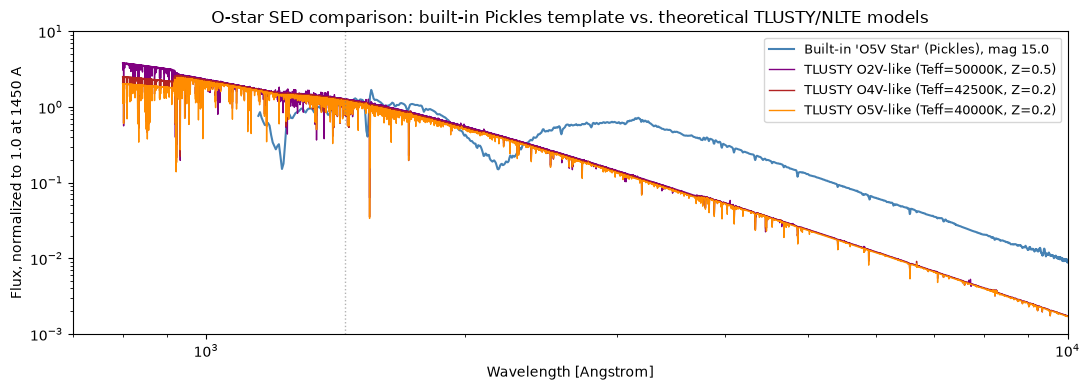

In [7]:
import matplotlib.pyplot as plt

# --- Load the three theoretical TLUSTY/NLTE model spectra ---
tlusty_models = {
    "O2V-like (Teff=50000K, Z=0.5)": "hlsp_nlte-obgrid_tlusty208_model_z05t50000g400v10_r5000_v1_spec.fits",
    "O4V-like (Teff=42500K, Z=0.2)": "hlsp_nlte-obgrid_tlusty208_model_z02t42500g400v10_r5000_v1_spec.fits",
    "O5V-like (Teff=40000K, Z=0.2)": "hlsp_nlte-obgrid_tlusty208_model_z02t40000g400v10_r5000_v1_spec.fits",
}

tlusty_data = {}
for label, filename in tlusty_models.items():
    with fits.open(filename) as hdul:
        d = hdul[1].data
        tlusty_data[label] = (d["wavelength"].astype(float), d["flux"].astype(float))

# --- Built-in O5V Star (Pickles atlas) ---
mag_cmp = 15.0
star_builtin = Source()
star_builtin.set_sed("O5V Star", mag_cmp, 0.0, 0.0, bandpass="galex,fuv")
wave_builtin = star_builtin.sed.waveset
flux_builtin = syn.units.convert_flux(wave_builtin, star_builtin.sed(wave_builtin), syn.units.FLAM).value

# --- Normalize everything to its own value at a common reference wavelength ---
# These are on wildly different absolute scales: the TLUSTY models are theoretical
# stellar-surface fluxes (~1e9 erg/s/cm2/A), while the built-in template is normalized
# to an apparent AB magnitude (~1e-13). Comparing them meaningfully means comparing
# SHAPE, not absolute level -- so everything is scaled to 1.0 at ref_wave.
ref_wave = 1450.0  # Angstrom -- inside all four spectra's real coverage

def flux_at(wave, flux, wave0):
    return np.interp(wave0, wave, flux)

fig, ax = plt.subplots(figsize=(11, 4))

builtin_wave_aa = wave_builtin.to_value(u.AA)
norm_builtin = flux_at(builtin_wave_aa, flux_builtin, ref_wave)
ax.plot(builtin_wave_aa, flux_builtin / norm_builtin,
        label=f"Built-in 'O5V Star' (Pickles), mag {mag_cmp}", color="steelblue", linewidth=1.5)

colors = {"O2V-like (Teff=50000K, Z=0.5)": "purple",
          "O4V-like (Teff=42500K, Z=0.2)": "firebrick",
          "O5V-like (Teff=40000K, Z=0.2)": "darkorange"}

for label, (wave, flux) in tlusty_data.items():
    norm = flux_at(wave, flux, ref_wave)
    ax.plot(wave, flux / norm, label=f"TLUSTY {label}", color=colors[label], linewidth=1)

ax.axvline(ref_wave, color="gray", linestyle=":", linewidth=1, alpha=0.6)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlim(700, 10000)
ax.set_ylim(1.e-3, 10)
ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel(f"Flux, normalized to 1.0 at {ref_wave:.0f} A")
ax.set_title("O-star SED comparison: built-in Pickles template vs. theoretical TLUSTY/NLTE models")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 5. Build the HWO EAC5 telescope and UV-IFS instrument model

The notebook now constructs the HWO **EAC5** telescope model and identifies the available UV integral-field spectrograph channels. Because the current development software can encounter duplicated-optic or configuration issues while building the complete telescope, the code includes a fallback that loads the UV-IFU channels directly from the HWO hardware data model.

A second current implementation detail is that the `IFS.band` setter is not used here. Instead, the selected band is read directly from each instrument configuration and supplied explicitly to `calculate(custom_band=...)`.


### 5.1 Construct the EAC5 telescope and locate the UV-IFS channels


In [8]:
from hwome.core.navigator import DataModel

hwo = Telescope()

try:
    hwo.set_from_hwome("EAC5")
    uv_ifs_keys = [name for name in hwo.instruments if ("IFU" in name or "IFS" in name)]

except Exception as e:
    print(f"hwo.set_from_hwome('EAC5') failed: {type(e).__name__}: {e}")
    print("Falling back to loading ONLY the UV_IFU channels directly.\n")

    hwo.name = "eac5"
    hwo.hwo_data = DataModel()
    hwo.hwo_data.load_hardware("eac5.yaml")
    hwo.instruments = {}
    hwo.telescope_bands = {}
    hwo.effective_diameter = hwo.hwo_data.OTA.circumscribing_diameter.q

    uv_ifu_data = hwo.hwo_data.UV_IFU
    modenames = list(uv_ifu_data.Channel.name.keys())

    uv_ifs_keys = []
    for modename in modenames:
        try:
            tel_instrument = IFS(hwo)
            tel_instrument.set_from_hwome(modename, "ifs")
            if tel_instrument.configuration["channel_filters"]:
                key = f"{modename}_IFS"
                hwo.instruments[key] = tel_instrument
                uv_ifs_keys.append(key)
                print(f"  OK      {key}")
            else:
                print(f"  SKIPPED {modename}  (no filters found)")
        except Exception as e2:
            print(f"  FAILED  {modename}  -- {type(e2).__name__}: {e2}")

print("\nUV IFS instruments available:", uv_ifs_keys)
if not uv_ifs_keys:
    raise RuntimeError("No UV_IFU/IFS instruments were loaded, even via the fallback path.")



UV IFS instruments available: ['UV_IFU.UV_IFU_Group1_IFS', 'UV_IFU.UV_IFU_Group2_IFS', 'UV_IFU.UV_IFU_Group3_IFS', 'UV_IFU.UV_IFU_Group4_IFS']


### 5.2 Catalog the available UV-IFS band configurations

For each UV-IFS channel, this cell records the corresponding IFS band, resolving power, and nominal wavelength interval. In the current EAC5 hardware definition, the available UV-IFS configurations have **R ≈ 4000**; their principal distinction here is wavelength coverage.


In [9]:
band_options = {}  # label -> (group_name, band_name)
for group_name in uv_ifs_keys:
    inst = hwo.instruments[group_name]
    for band_name, band_info in inst.configuration["band"].items():
        if band_info.get("kind") != "disperser":
            continue
        R = band_info["resolution"]
        Rval = R.value if hasattr(R, "value") else R
        wmin = band_info["wave_min"].to_value(u.AA) if hasattr(band_info["wave_min"], "to_value") else band_info["wave_min"]
        wmax = band_info["wave_max"].to_value(u.AA) if hasattr(band_info["wave_max"], "to_value") else band_info["wave_max"]
        label = f"{group_name.split('.')[1].replace('_IFS','')}  (R~{Rval:.0f}, {wmin:.0f}-{wmax:.0f} A)"
        band_options[label] = (group_name, band_name)

print("Available (group, band) options:")
for label, (g, b) in band_options.items():
    print(f"  {label}  ->  group={g}, band={b}")

default_label = list(band_options.keys())[0]

# Wavelength intervals over which the ETC S/N calculation is considered valid.
# These limits are kept separate from the padded plotting range used by the dashboard.
SNR_VALID_RANGES = {
    "UV_IFU.UV_IFU_Group1_IFS": (1247.0, 1902.0),
    "UV_IFU.UV_IFU_Group2_IFS": (1234.0, 1914.0),
    "UV_IFU.UV_IFU_Group3_IFS": (2024.0, 3826.0),
    "UV_IFU.UV_IFU_Group4_IFS": (2014.0, 3819.0),
}



Available (group, band) options:
  UV_IFU_Group1  (R~4000, 1215-1869 A)  ->  group=UV_IFU.UV_IFU_Group1_IFS, band=UV_IFU_Group1.UV_IFU_F1
  UV_IFU_Group2  (R~4000, 1205-1884 A)  ->  group=UV_IFU.UV_IFU_Group2_IFS, band=UV_IFU_Group2.UV_IFU_F1
  UV_IFU_Group3  (R~4000, 2014-3814 A)  ->  group=UV_IFU.UV_IFU_Group3_IFS, band=UV_IFU_Group3.UV_IFU_F3
  UV_IFU_Group4  (R~4000, 2004-3808 A)  ->  group=UV_IFU.UV_IFU_Group4_IFS, band=UV_IFU_Group4.UV_IFU_F3


## 6. Register external spectra as `syotools` source templates

The ETC expects source spectra to be available through the `syotools` spectral library. The helper functions below provide the bridge between external FITS spectra and `Source.set_sed()`.

`register_custom_template()` converts wavelength and FLAM arrays into a `synphot` source spectrum and registers it in the library. `load_tlusty_model()` reads one of the downloaded theoretical NLTE spectra and registers it for normal GALEX-FUV magnitude normalization.

The notebook also retains the earlier `load_ullyses_source()` and `set_sed_narrowband()` helpers as **optional compatibility code for empirical ULLYSES/COS spectra**. Those functions are not used by the three TLUSTY targets in the current calculation; they remain available for a later empirical-versus-theoretical comparison.


### 6.1 Define custom-template, optional ULLYSES, and TLUSTY loading helpers


In [10]:
def register_custom_template(name, wavelength_aa, flux, renorm_band="galex,fuv"):
    """Register a custom SED so that Source.set_sed(name, ...) can use it, exactly like
    the built-in templates.

    Parameters
    ----------
    name : str
        The template name passed to Source.set_sed(), and what appears in this
        notebook's Template dropdown.
    wavelength_aa : array-like
        Wavelength grid, in Angstroms.
    flux : array-like
        Spectral flux-density values represented internally in
        erg/s/cm^2/Angstrom (FLAM), with the same length as wavelength_aa.
    
        For theoretical atmosphere models such as TLUSTY, these values are
        stellar-surface fluxes. Their native absolute normalization is retained
        when the template is registered, but it is not interpreted as the
        apparent flux at the telescope. Source.set_sed() subsequently rescales
        the spectral shape to the requested apparent magnitude before the ETC
        calculation.
    renorm_band : str
        Bandpass name used by Source.set_sed() if no explicit bandpass is given there.
    """
    wave_q = np.asarray(wavelength_aa) << u.AA
    flux_q = np.asarray(flux) << (u.erg / u.s / u.cm**2 / u.AA)
    new_sed = syn.spectrum.SourceSpectrum(syn.models.Empirical1D, points=wave_q, lookup_table=flux_q)
    new_sed.band = renorm_band
    syn_spectra_library[name] = new_sed
    print(f"Registered '{name}' with {len(wave_q)} points, "
          f"{wave_q.min():.1f}-{wave_q.max():.1f}, renorm band '{renorm_band}'.")


def load_ullyses_source(
    target_slug,
    target_label,
    template_name,
    grating="g130m",
    release="dr7",
    renorm_band="galex,fuv",
):
    """Download (if not already on disk) and register a ULLYSES DR7 stellar spectrum
    from MAST as a spectral template usable by Source.set_sed(). Also records a safe
    narrowband normalization window for this template in CUSTOM_NORM_WINDOW (see
    set_sed_narrowband below), computed from the template's own real data range.
    """
    HLSP_FILENAME = f"hlsp_ullyses_hst_cos_{target_slug}_{grating}_{release}_cspec.fits"
    MAST_URI = f"mast:HLSP/ullyses/{target_slug}/{release}/{HLSP_FILENAME}"

    if not os.path.exists(HLSP_FILENAME):
        try:
            from astroquery.mast import Observations
        except ImportError:
            import sys, subprocess
            subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "astroquery"], check=True)
            from astroquery.mast import Observations

        print(f"Downloading {HLSP_FILENAME} ...")
        try:
            Observations.download_file(uri=MAST_URI)
            print(f"  via direct MAST URI: {MAST_URI}")
        except Exception as e:
            print(f"  direct URI failed ({type(e).__name__}: {e}); falling back to a product search...")
            obs = Observations.query_criteria(obs_collection="HLSP", provenance_name="ULLYSES",
                                               target_name=target_slug.upper())
            if len(obs) == 0:
                raise RuntimeError(
                    f"No ULLYSES HLSP observations found for target_name={target_slug.upper()!r}. "
                    "This target may be indexed under a different string in MAST -- try "
                    "Observations.query_criteria(obs_collection='HLSP', provenance_name='ULLYSES') "
                    "alone and inspect obs['target_name'] for the real string."
                )
            products = Observations.get_product_list(obs)
            filtered = Observations.filter_products(products, productFilename=HLSP_FILENAME)
            if len(filtered) == 0:
                raise RuntimeError(
                    f"Query succeeded ({len(products)} products found) but none matched filename "
                    f"{HLSP_FILENAME!r} exactly -- print(products['productFilename']) to see what's "
                    "actually available for this target."
                )
            manifest = Observations.download_products(filtered)
            print(manifest)
            HLSP_FILENAME = manifest["Local Path"][0]
    else:
        print(f"{HLSP_FILENAME} already on disk, skipping download.")

    with fits.open(HLSP_FILENAME) as hdul:
        sci = hdul[1].data
        wave = np.asarray(sci["WAVELENGTH"], dtype=float).ravel()
        flux = np.asarray(sci["FLUX"], dtype=float).ravel()

    good = np.isfinite(wave) & np.isfinite(flux)
    wave, flux = wave[good], flux[good]

    print(f"{target_label}: {len(wave)} points, {wave.min():.1f}-{wave.max():.1f} Angstrom")

    bp = stsyn.band(renorm_band)
    bp_wave = bp.waveset.to_value(u.AA)
    if bp_wave.min() < wave.min() or bp_wave.max() > wave.max():
        print(f"NOTE: {renorm_band} extends outside {target_label}'s observed wavelength range -- "
              f"will use a narrow synthetic bandpass for normalization instead (see below).")

    register_custom_template(template_name, wave, flux, renorm_band=renorm_band)

    # A safe normalization window for this template: centered in the real data,
    # comfortably inside it, used by set_sed_narrowband() whenever this specific
    # template is selected (see compute_and_render()).
    #
    # Width matters a lot here: a real O-star FUV spectrum is heavily line-blanketed,
    # not smooth like the built-in synthetic library templates. A too-narrow window
    # (e.g. 20 A) can land right on an absorption feature or a locally brighter/fainter
    # patch, making the normalization wildly sensitive to exactly where it happens to
    # sit -- confirmed as the cause of a several-times flux/SNR mismatch against the
    # built-in 'O5V Star' template at the same nominal magnitude. Using 80% of the
    # real data range instead averages over most of the spectrum's actual structure,
    # much closer in spirit to how an integrated bandpass like galex,fuv (~440 A wide)
    # averages over a real continuum -- though it still won't exactly match galex,fuv's
    # calibration, since that band's effective wavelength (~1528-1550 A) sits entirely
    # outside this data's real coverage; the two are unavoidably different reference
    # points for a source with real wavelength-dependent structure.
    center = (float(wave.min()) + float(wave.max())) / 2.0 * u.AA
    width = 0.8 * (float(wave.max()) - float(wave.min())) * u.AA
    CUSTOM_NORM_WINDOW[template_name] = (center, width)

    # This template's REAL wavelength coverage, used by compute_and_render() to set the
    # SED plot's x-range -- these spectra only have real data over a few hundred
    # Angstroms, so the built-in templates' fixed "cap at 10000 A" rule (tuned for
    # QSO/O5V Star's much broader native range) doesn't make sense here; it would just
    # show a long stretch of extrapolated/zero flux beyond the real data.
    CUSTOM_WAVE_RANGE[template_name] = (float(wave.min()), float(wave.max()))

    return wave, flux


def set_sed_narrowband(source, source_name, magnitude, redshift, extinction,
                        center_wavelength, width, library=syn_spectra_library):
    """Like Source.set_sed(), but normalizes against a narrow synthetic top-hat bandpass
    (center_wavelength +/- width/2) instead of a named bandpass like 'galex,fuv' -- for
    templates whose real data doesn't fully cover a standard bandpass.
    """
    source.name = source_name
    source.magnitude = magnitude
    source.redshift = redshift
    source.extinction = extinction
    source.renorm_band = f"box(center={center_wavelength}, width={width})"

    narrow_band = SpectralElement(Box1D, x_0=center_wavelength, width=width)

    new_sed = library[source_name]
    new_sed.z = redshift
    sp_ext = new_sed * syn.reddening.ReddeningLaw.from_extinction_model('mwavg').extinction_curve(extinction)
    sp_norm = sp_ext.normalize(magnitude * u.ABmag, band=narrow_band)
    source.sed = sp_norm
    return source



def load_tlusty_model(filepath, template_name, renorm_band="galex,fuv"):
    """Load a theoretical TLUSTY/NLTE OB-star model spectrum from a LOCAL FITS file
    (downloaded from the STScI nlte-obgrid HLSP) and register it as a template.

    Unlike load_ullyses_source(), this doesn't download anything from MAST -- the
    file must already be on disk -- and doesn't populate CUSTOM_NORM_WINDOW /
    CUSTOM_WAVE_RANGE, since these theoretical models span 800-320,000+ A,
    comfortably covering galex,fuv on their own. compute_and_render() already
    falls through to the normal Source.set_sed(..., bandpass="galex,fuv") path
    for any template not in CUSTOM_NORM_WINDOW, so no other changes are needed
    there.
    """
    with fits.open(filepath) as hdul:
        d = hdul[1].data
        wave = d["wavelength"].astype(float)
        flux = d["flux"].astype(float)

    good = np.isfinite(wave) & np.isfinite(flux)
    wave, flux = wave[good], flux[good]

    print(f"{template_name}: {len(wave)} points, {wave.min():.1f}-{wave.max():.1f} Angstrom "
          f"(theoretical surface flux, arbitrary absolute scale -- Source.set_sed() will "
          f"rescale it to whatever magnitude you set)")

    register_custom_template(template_name, wave, flux, renorm_band=renorm_band)
    return wave, flux


### 6.2 Register the configured TLUSTY models

Each model listed in `TARGETS` is now read from its downloaded FITS file and added to `syn_spectra_library`. Because these theoretical spectra extend well beyond the GALEX FUV band, they use the standard `Source.set_sed(..., bandpass="galex,fuv")` normalization path.


In [11]:
CUSTOM_NORM_WINDOW = {}  # unused for TLUSTY models, kept for compatibility with compute_and_render()
CUSTOM_WAVE_RANGE = {}   # unused for TLUSTY models, kept for compatibility with compute_and_render()

for name, cfg in TARGETS.items():
    print(f"=== {name} ===")
    load_tlusty_model(
        filepath=cfg["filepath"],
        template_name=cfg["template_name"],
        renorm_band=cfg["renorm_band"],
    )
    print()


=== TLUSTY O2V (Teff=50000K) ===
O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun): 29957 points, 800.0-320039.2 Angstrom (theoretical surface flux, arbitrary absolute scale -- Source.set_sed() will rescale it to whatever magnitude you set)
Registered 'O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun)' with 29957 points, 800.0 Angstrom-320039.2 Angstrom, renorm band 'galex,fuv'.

=== TLUSTY O4V (Teff=42500K) ===
O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun): 29957 points, 800.0-320039.2 Angstrom (theoretical surface flux, arbitrary absolute scale -- Source.set_sed() will rescale it to whatever magnitude you set)
Registered 'O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun)' with 29957 points, 800.0 Angstrom-320039.2 Angstrom, renorm band 'galex,fuv'.

=== TLUSTY O5V (Teff=40000K) ===
O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun): 29957 points, 800.0-320039.2 Angstrom (theoretical surface flux, arbitrary absolute scale -- Source.set_sed() 

### 6.3 What stellar templates are available right now?

In [12]:
print("Templates available in syn_spectra_library:")
for name in sorted(syn_spectra_library.keys()):
    print("  ", name)


Templates available in syn_spectra_library:
   10 Myr Starburst
   B5V Star
   Blackbody (100,000K)
   Blackbody (5000K)
   Classical T-Tauri Star
   Elliptical Galaxy
   Flat (AB)
   Flat in F_lambda
   G Dwarf
   G191B2B (WD)
   G2V Star
   GD153 (WD)
   GD71 (WD)
   Galaxy with f_esc, HI=0.001, HeI=1
   Galaxy with f_esc, HI=1, HeI=1
   Liner
   M Dwarf
   M1 Dwarf
   M2V Star
   NGC 1068
   O2V-like TLUSTY model (Teff=50000K, logg=4.0, Z=0.5 Zsun)
   O4V-like TLUSTY model (Teff=42500K, logg=4.0, Z=0.2 Zsun)
   O5V Star
   O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun)
   Orion Nebula
   QSO
   Sbc Galaxy
   Seyfert 1
   Seyfert 2
   Starburst, E(B-V) = 0.6
   Starburst, No Dust


## 7. Initialize the default UV-IFS source and exposure

This cell creates a baseline UV-IFS exposure used to verify that the instrument model is working before the interactive dashboard is launched.

For consistency with the STScI HWO IFS ETC comparison, the baseline configuration is:

- **O5V Star**
- **GALEX FUV AB magnitude = 15**
- **10 m telescope aperture**
- **1 hour exposure**
- the first available UV-IFS band configuration

The interactive dashboard in Section 10 starts from the same values.


### 7.1 Create the default source, exposure, and template list


In [13]:
GROUP_NAME, BAND_NAME = band_options[default_label]
uvi = hwo.instruments[GROUP_NAME]

# Baseline source used for validation and for the initial dashboard state.
template = "O5V Star"
fuvmag = 15.0
bandpass = "galex,fuv"
redshift = 0
extinction = 0

# Keep the telescope model at the EAC5 10 m comparison aperture.
hwo.effective_diameter = 10.0 * u.m

uvi_sed = Source()
uvi_sed.set_sed(template, fuvmag, redshift, extinction, bandpass=bandpass)

# Create a fresh exposure after the telescope aperture has been set.
# This ordering is important: SourceIFSExposure stores telescope state when it
# is created, so reusing an old exposure after changing the aperture can leave
# the exposure attached to the previous aperture value.
uvi_exposure = uvi.create_exposure(source=uvi_sed)
# Convert explicitly to seconds: syotools count rates are in ct/s.
#uvi_exposure.exptime = (1.0 * u.h).to(u.s)
uvi_exposure.exptime = (1.0 * u.h)
uvi_exposure.unknown = "snr"
uvi_exposure.calculate(custom_band=BAND_NAME)

band_info = uvi.configuration["band"][BAND_NAME]
print(f"Default band: {default_label}")
print(f"Default template: {template}, FUV AB mag {fuvmag:.1f}")
print("Default aperture: 10.0 m")
print("Default exposure: 1.0 h")
print(f"R = {band_info['resolution']}, range = {band_info['wave_min']:.1f}-{band_info['wave_max']:.1f} A")

available_templates = sorted(syn_spectra_library.keys())
print(f"\n{len(available_templates)} templates available (including registered TLUSTY models).")


Default band: UV_IFU_Group1  (R~4000, 1215-1869 A)
Default template: O5V Star, FUV AB mag 15.0
Default aperture: 10.0 m
Default exposure: 1.0 h
R = 4000.0, range = 1215.3 Angstrom-1869.4 Angstrom A

31 templates available (including registered TLUSTY models).


## 8. Define the interactive SED and SNR visualization

The dashboard displays two linked Chart.js panels: the source **spectral energy distribution (SED)** and the ETC **signal-to-noise ratio (SNR)**. The plotting helper converts the calculated arrays into an HTML/JavaScript visualization with linked x-axis pan and zoom.

In the SNR panel, a **shaded vertical region marks the wavelength interval over which the ETC S/N calculation is considered valid for the selected UV-IFS group**. The limits are taken explicitly from the UV-IFS configuration table used in this notebook:

- Group 1: 1247–1902 Å
- Group 2: 1234–1914 Å
- Group 3: 2024–3826 Å
- Group 4: 2014–3819 Å

The SNR plot itself retains a small wavelength padding outside these limits so that the boundaries of the valid interval are visually obvious. The shaded region, not the full displayed x-range, identifies the interval that should be interpreted scientifically.

The optional sky-background helper is retained for future use, although the current dashboard does not draw the sky spectrum.


### 8.1 Build the Chart.js rendering helpers


In [14]:
def band_matched_sky(band_info):
    """A flat 24 ABmag/pixel placeholder background spanning the real band wavelength
    grid -- same construction IFS.band's (broken) setter would do internally.
    Currently unused (see render_charts) -- kept in case the sky overlay is wanted back."""
    wave = band_info["bandpass"].waveset
    sky = syn.spectrum.SourceSpectrum(Empirical1D, points=wave,
                                       lookup_table=np.ones_like(wave.value) * 24 << u.ABmag)
    sky = sky.normalize(24 * u.ABmag, stsyn.spectrum.band("johnson,v"))
    return sky

def render_charts(wave_sed, flux, bgwave, bgflux, wave_snr, snr_vals, xr_sed, xr_snr, valid_snr_range, title_suffix=""):
    """Build two Chart.js line charts (SED log-scale, SNR linear-scale) as one HTML block,
    with independent, intuitive pan/zoom on the x-axis via chartjs-plugin-zoom. The SNR panel shades
    the wavelength interval over which the ETC S/N calculation is considered valid.

    IMPORTANT: script loading is handled with an explicit Promise-based sequential
    loader (see loadScript() in the generated JS below), NOT plain <script src="...">
    tags. Confirmed via browser console (`ReferenceError: Can't find variable: Chart`)
    that Jupyter's HTML-output rendering doesn't guarantee <script src="..."> tags
    execute in order (or even complete) before subsequent inline code runs -- dynamically
    inserted script elements load asynchronously by default, so the three CDN scripts
    (Chart.js, Hammer.js, chartjs-plugin-zoom) and our chart-creation code were racing
    each other. Explicitly waiting for each script's 'load' event before proceeding
    fixes this regardless of Jupyter's internal script-injection mechanics.
    """
    uid = np.random.randint(1_000_000_000)  # unique element IDs, avoids any stale-canvas reuse issues

    # Chart.js log axis can't render y<=0 -- drop those points rather than clamp them,
    # so gaps in the line are visually honest about where there's literally no signal.
    def xy_pairs(x, y, positive_only=False):
        pts = []
        for xi, yi in zip(x, y):
            if not np.isfinite(xi) or not np.isfinite(yi):
                continue
            if positive_only and yi <= 0:
                continue
            pts.append({"x": float(xi), "y": float(yi)})
        return pts

    sed_data = xy_pairs(wave_sed, flux, positive_only=True)
    snr_data = xy_pairs(wave_snr, snr_vals, positive_only=False)
    # Sky background overlay commented out (see compute_and_render()). To restore:
    # uncomment the sky_data line below and add the second dataset object back into
    # the SED chart's `datasets` array.
    # sky_data = xy_pairs(bgwave, bgflux, positive_only=True)

    # Compact log-axis tick labels (e.g. "2.0e-17") instead of JS's default full-precision
    # decimal string for very small/large floats.
    log_tick_formatter = "function(value) { return value === 0 ? '0' : value.toExponential(1); }"

    html = f"""
    <div style="display:flex; flex-direction:column; gap:10px;">
      <canvas id="sed_{uid}" width="600" height="300"></canvas>
      <canvas id="snr_{uid}" width="600" height="300"></canvas>
      <button id="reset_{uid}" style="align-self:flex-start; padding:4px 12px;">Reset view</button>
    </div>
    <script>
    (function() {{
        // --- Sequential script loader: waits for each script's real 'load' event
        // before starting the next, and before running any chart-creation code.
        // Skips re-loading anything already present from a previous render. ---
        function loadScript(src) {{
            return new Promise(function(resolve, reject) {{
                var script = document.createElement('script');
                script.src = src;
                script.onload = function() {{ resolve(); }};
                script.onerror = function() {{ reject(new Error('Failed to load ' + src)); }};
                document.head.appendChild(script);
            }});
        }}

        function buildCharts() {{
            let sedChart, snrChart, syncing = false;

            // chartjs-plugin-zoom's `limits` option only constrains INTERACTIVE
            // gestures (mouse drag, wheel, pinch) on a chart's own canvas -- it does
            // NOT automatically clamp programmatic zoomScale() calls, which is exactly
            // what cross-chart syncing uses. So syncing an unrestricted SED pan/zoom
            // straight onto the SNR chart bypassed its limit entirely.
            //
            // Rather than trying to preserve the incoming window's width (which
            // degenerated to "just show SNR's full range" almost always, since SED's
            // typical view is thousands of Angstroms wide -- much wider than SNR's
            // ~786 A valid range -- making SNR look frozen/unresponsive to panning),
            // show the INTERSECTION of the SNR panel's plotted range with the SED
            // chart's current viewport. The plotted range includes a small padding
            // around the scientifically valid S/N interval so the validity boundaries
            // remain visible.
            const SNR_PLOT_MIN = {xr_snr[0]};
            const SNR_PLOT_MAX = {xr_snr[1]};
            const SNR_VALID_MIN = {valid_snr_range[0]};
            const SNR_VALID_MAX = {valid_snr_range[1]};

            // Lightweight local Chart.js plugin: draw a translucent rectangle behind
            // the SNR data between the exact validity limits. This avoids adding an
            // additional annotation-plugin dependency.
            const snrValidityRegion = {{
                id: 'snrValidityRegion',
                beforeDatasetsDraw(chart, args, options) {{
                    if (!options || options.xMin == null || options.xMax == null) return;
                    const xScale = chart.scales.x;
                    const area = chart.chartArea;
                    const left = Math.max(area.left, xScale.getPixelForValue(options.xMin));
                    const right = Math.min(area.right, xScale.getPixelForValue(options.xMax));
                    if (right <= left) return;
                    const ctx = chart.ctx;
                    ctx.save();
                    ctx.fillStyle = 'rgba(110, 110, 110, 0.16)';
                    ctx.fillRect(left, area.top, right - left, area.bottom - area.top);
                    ctx.restore();
                }}
            }};

            function syncPanZoom(which) {{
                return function(ctx) {{
                    if (syncing) return;
                    syncing = true;
                    const {{min, max}} = ctx.chart.scales.x;
                    if (which === 'sed') {{
                        const newMin = Math.max(min, SNR_PLOT_MIN);
                        const newMax = Math.min(max, SNR_PLOT_MAX);
                        if (newMin < newMax) {{
                            snrChart.zoomScale('x', {{min: newMin, max: newMax}}, 'none');
                        }}
                        // else: no overlap at all between SED's current view and SNR's
                        // valid range -- leave SNR showing whatever it last had, since
                        // there's nothing meaningful to display otherwise.
                    }} else {{
                        // SNR's own gesture is already clamped to its valid range by
                        // `limits` -- apply the same window directly to the
                        // (unrestricted) SED chart.
                        sedChart.zoomScale('x', {{min: min, max: max}}, 'none');
                    }}
                    syncing = false;
                }};
            }}

            sedChart = new Chart(document.getElementById('sed_{uid}'), {{
                type: 'line',
                data: {{ datasets: [
                    {{label: 'Source SED{title_suffix}', data: {_json.dumps(sed_data)},
                     borderColor: 'firebrick', pointStyle: 'circle', pointRadius: 0, borderWidth: 2, showLine: true}}
                ]}},
                options: {{
                    animation: false,
                    scales: {{
                        x: {{type: 'linear', min: {xr_sed[0]}, max: {xr_sed[1]},
                             title: {{display: true, text: 'Wavelength [Angstrom]'}}}},
                        y: {{type: 'logarithmic',
                             title: {{display: true, text: 'Flux [erg / s / cm2 / Ang]'}},
                             ticks: {{callback: {log_tick_formatter}}}}}
                    }},
                    plugins: {{
                        legend: {{labels: {{usePointStyle: true}}}},
                        title: {{display: false, text: 'SED'}},
                        zoom: {{
                            pan: {{
                                enabled: true,
                                mode: 'x',
                                threshold: 4
                            }},
                            zoom: {{
                                wheel: {{
                                    enabled: true,
                                    speed: 0.08
                                }},
                                pinch: {{
                                    enabled: true
                                }},
                                mode: 'x'
                            }}
                        }}
                    }}
                }}
            }});

            snrChart = new Chart(document.getElementById('snr_{uid}'), {{
                type: 'line',
                plugins: [snrValidityRegion],
                data: {{ datasets: [
                    {{label: 'SNR', data: {_json.dumps(snr_data)},
                     borderColor: 'orange', pointStyle: 'circle', pointRadius: 0, borderWidth: 2, showLine: true}}
                ]}},
                options: {{
                    animation: false,
                    scales: {{
                        x: {{type: 'linear', min: {xr_snr[0]}, max: {xr_snr[1]},
                             title: {{display: true, text: 'Wavelength [Angstrom]'}}}},
                        y: {{type: 'linear', min: 0,
                             title: {{display: true, text: 'S/N per resolution element'}}}}
                    }},
                    plugins: {{
                        legend: {{labels: {{usePointStyle: true}}}},
                        title: {{display: false, text: 'SNR'}},
                        subtitle: {{display: true, text: 'Shaded region: valid S/N interval ({valid_snr_range[0]:.0f}-{valid_snr_range[1]:.0f} Angstrom)'}},
                        snrValidityRegion: {{xMin: SNR_VALID_MIN, xMax: SNR_VALID_MAX}},
                        zoom: {{
                            // Keep SNR interaction within the displayed numerical S/N support.
                            // The shaded interval remains the scientifically valid range.
                            limits: {{
                                x: {{
                                    min: {xr_snr[0]},
                                    max: {xr_snr[1]},
                                    minRange: 5
                                }}
                            }},
                            pan: {{
                                enabled: true,
                                mode: 'x',
                                threshold: 4
                            }},
                            zoom: {{
                                wheel: {{
                                    enabled: true,
                                    speed: 0.08
                                }},
                                pinch: {{
                                    enabled: true
                                }},
                                mode: 'x'
                            }}
                        }}
                    }}
                }}
            }});

            document.getElementById('reset_{uid}').addEventListener('click', function() {{
                sedChart.resetZoom();
                snrChart.resetZoom();
            }});
        }}

        if (window.Chart && window.Chart.Zoom) {{
            // Already loaded from a previous render in this same page -- skip straight
            // to building the charts, no need to re-fetch anything from the CDN.
            buildCharts();
        }} else {{
            loadScript('https://cdn.jsdelivr.net/npm/chart.js@4')
                .then(function() {{ return loadScript('https://cdn.jsdelivr.net/npm/hammerjs@2.0.8/hammer.min.js'); }})
                .then(function() {{ return loadScript('https://cdn.jsdelivr.net/npm/chartjs-plugin-zoom@2'); }})
                .then(buildCharts)
                .catch(function(err) {{ console.error('Chart.js loading failed:', err); }});
        }}
    }})();
    </script>
    """
    return HTML(html)


## 9. Run the UV-IFS ETC calculation

`compute_and_render()` is the central calculation wrapper used by the dashboard. For each requested configuration it:

1. selects the requested UV-IFS group and band;
2. applies the requested telescope aperture **before constructing a new exposure**;
3. creates a fresh source and exposure so that no telescope, source, or exposure-time state is inherited from the previous dashboard calculation;
4. normalizes the selected source to the requested **GALEX FUV AB magnitude**;
5. calculates the UV-IFS S/N;
6. plots the source SED and the full numerical S/N result returned by the ETC; and
7. shades the nominal wavelength interval over which the selected UV-IFS group's S/N is considered scientifically valid.

The ETC wavelength grid is broader than the nominal valid interval. For example, Group 1 can return positive numerical S/N outside 1247–1902 Å. The shaded region therefore denotes the adopted **valid science interval**, not the full numerical support of the underlying ETC array.


<div style="
    background-color:#fff4e5;
    border:2px solid #d97706;
    border-left:8px solid #d97706;
    padding:14px 16px;
    margin:14px 0;
    color:#7c2d12;
">
This notebook therefore converts all user-facing exposure times from hours to seconds <strong>before</strong> assigning
<code>exposure.exptime</code>. The dashboard still displays exposure time in hours.
</div>


### 9.1 Calculate the selected configuration and prepare the plots


## 10. Launch the interactive HWO UV-IFS ETC dashboard

This cell assembles the `ipywidgets` controls and the linked SED/SNR display. The dashboard starts from the same configuration used for the STScI comparison: **O5V Star, 10 m aperture, 1 h exposure, FUV AB = 15**.

Each click on **Update plots** performs exactly one ETC calculation. A fresh source and exposure are created for that calculation, so changing the aperture, exposure time, magnitude, template, or UV-IFS band cannot leave stale state from an earlier run.

A compact status line above the plots reports the values used for the current calculation. The S/N plot displays the full numerical wavelength support returned by the ETC, while the shaded region marks the nominal valid S/N interval for the selected UV-IFS group.


### Plot navigation

Each plot now navigates independently:

- **Scroll** over a plot to zoom the wavelength axis.
- **Pinch** on a trackpad to zoom.
- **Click and drag horizontally** to pan.
- Use **Reset view** to return that panel to its original wavelength range.

The SED and S/N panels are intentionally not synchronized because their scientifically useful wavelength ranges are different.


In [15]:
def compute_and_render(template, aperture, exptime, fuv_magnitude, band_label):
    global uvi, uvi_exposure, GROUP_NAME, BAND_NAME

    # The detector thermal-background Planck-law calculation can overflow exp()
    # at UV wavelengths for a cold detector. The corresponding thermal term tends
    # to zero there, so these benign overflow warnings are suppressed.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="overflow encountered in exp")

        # Select the requested instrument configuration.
        GROUP_NAME, BAND_NAME = band_options[band_label]
        uvi = hwo.instruments[GROUP_NAME]

        # IMPORTANT STATE-HANDLING RULE:
        # Set the telescope aperture BEFORE creating the exposure. Reusing the
        # exposure created in Section 6 can retain the telescope state present when
        # that exposure was originally constructed.
        hwo.effective_diameter = aperture * u.m

        # Build a fresh source for every calculation so that the magnitude and
        # template shown in the dashboard are exactly those used by the ETC.
        source = Source()

        if template in CUSTOM_NORM_WINDOW:
            center_wavelength, width = CUSTOM_NORM_WINDOW[template]
            set_sed_narrowband(
                source, template, fuv_magnitude, redshift, extinction,
                center_wavelength, width
            )
        else:
            source.set_sed(
                template, fuv_magnitude, redshift, extinction,
                bandpass=bandpass
            )

        # Build a fresh exposure after both the aperture and source have been set.
        uvi_exposure = uvi.create_exposure(source=source)
        uvi_exposure.exptime = exptime * u.h
        uvi_exposure.unknown = "snr"
        uvi_exposure.calculate(custom_band=BAND_NAME)

        band_info = uvi.configuration["band"][BAND_NAME]
        wave = band_info["bandpass"].waveset
        snr = uvi_exposure.recover("snr")

        # Source SED on the instrument bandpass wavelength grid.
        flux = syn.units.convert_flux(
            wave,
            uvi_exposure.source.sed(wave),
            syn.units.FLAM
        ).value
        flux[~np.isfinite(flux)] = 0.0

        # S/N is returned with shape (1, N) in the current ETC implementation.
        # Preserve that dimensional meaning explicitly rather than flattening an
        # arbitrary multidimensional object with ravel().
        snr_array = np.asarray(snr)
        if snr_array.ndim == 2 and snr_array.shape[0] == 1:
            snr_vals = snr_array[0].copy()
        elif snr_array.ndim == 1:
            snr_vals = snr_array.copy()
        else:
            raise ValueError(
                f"Unexpected S/N array shape {snr_array.shape}; "
                "expected (N,) or (1, N)."
            )
        
        snr_wave = uvi_exposure.wave[0] * (u.AA)
        
        if len(snr_wave) != len(snr_vals):
            raise ValueError(
                "ETC wavelength and S/N arrays do not have a one-to-one "
                f"correspondence: {len(snr_wave)} wavelengths versus "
                f"{len(snr_vals)} S/N samples."
            )

        snr_vals[~np.isfinite(snr_vals)] = 0.0

        # Exact nominal wavelength interval over which the S/N result is considered
        # scientifically valid for the selected UV-IFS group.
        valid_snr_range = SNR_VALID_RANGES[GROUP_NAME]

        # Numerical S/N support returned by the ETC. This is intentionally kept
        # distinct from the nominal valid science interval above.
        positive = snr_vals > 0
        if np.any(positive):
            support_min = float(snr_wave[positive][0].value)
            support_max = float(snr_wave[positive][-1].value)
        else:
            support_min, support_max = valid_snr_range

        # SED x-range remains broad for comparison among the stellar templates.
        wmin, wmax = valid_snr_range
        valid_width = wmax - wmin
        xr_sed = (wmin - 0.1 * valid_width, 10000)

        # Show the full numerical S/N support with a modest amount of context.
        # The shaded area inside this range marks the nominal valid science interval.
        support_width = max(support_max - support_min, 1.0)
        xr_snr = (
            max(float(snr_wave.min().value), support_min - 0.05 * support_width),
            min(float(snr_wave.max().value), support_max + 0.05 * support_width),
        )

        # Sky background overlay is currently disabled.
        bgwave, bgflux = np.array([]), np.array([])

    chart = render_charts(
        wave.value, flux,
        bgwave, bgflux,
        snr_wave.value, snr_vals,
        xr_sed, xr_snr, valid_snr_range,
        title_suffix=f" ({template}, FUV AB {fuv_magnitude:.1f})"
    )

    # Return a compact status dictionary so the callback can display the exact
    # configuration associated with the current plot. This avoids stale diagnostic
    # output from previous calculations.
    
    status = {
        "template": template,
        "aperture_m": float(aperture),
        "exptime_h": float(exptime),
        "fuv_ab": float(fuv_magnitude),
        "band": band_label,
        "snr_support": (support_min, support_max),
        "valid_range": tuple(valid_snr_range),
    }

    return chart, status


### 10.1 Create the controls and render the initial ETC result


In [16]:
import ipywidgets as widgets
from ipywidgets import Layout, VBox, HBox

w_style = {'description_width': 'initial'}
w_layout = Layout(width='95%')

template_w = widgets.Dropdown(
    options=available_templates,
    value="O5V Star",
    description='Template:',
    style=w_style,
    layout=w_layout
)

aperture_w = widgets.FloatSlider(
    value=10.0,
    min=2.0,
    max=15.0,
    step=0.1,
    description='Aperture (m):',
    style=w_style,
    layout=w_layout
)

exptime_w = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=10.0,
    step=0.1,
    description='Exptime (h):',
    style=w_style,
    layout=w_layout
)

magnitude_w = widgets.FloatSlider(
    value=15.0,
    min=5.0,
    max=35.0,
    step=0.1,
    description='FUV mag (AB):',
    style=w_style,
    layout=w_layout
)

band_w = widgets.Dropdown(
    options=list(band_options.keys()),
    value=default_label,
    description='Band:',
    style=w_style,
    layout=w_layout
)

update_button = widgets.Button(
    description="Update plots",
    button_style='primary',
    layout=w_layout
)

output_area = widgets.Output()

# If a future TARGETS entry supplies an intrinsic/default apparent FUV magnitude,
# selecting that template can initialize the slider to it. The current theoretical
# TLUSTY entries intentionally do not define one.
def on_template_selected(change):
    new_template = change['new']
    for cfg in TARGETS.values():
        if cfg['template_name'] == new_template and 'fuv_magnitude' in cfg:
            magnitude_w.value = cfg['fuv_magnitude']
            break

template_w.observe(on_template_selected, names='value')


def on_update_clicked(b=None):
    # Everything associated with a dashboard update is produced inside the same
    # Output widget. clear_output() therefore removes the previous plot/status,
    # preventing stale diagnostics from being displayed beside a new calculation.
    with output_area:
        clear_output(wait=True)

        try:
            chart, status = compute_and_render(
                template_w.value,
                aperture_w.value,
                exptime_w.value,
                magnitude_w.value,
                band_w.value
            )

            print(
                f"ETC calculation: {status['template']} | "
                f"{status['aperture_m']:.1f} m | "
                f"{status['exptime_h']:.1f} h | "
                f"FUV AB {status['fuv_ab']:.1f}"
            )
            print(
                f"Numerical S/N support: "
                f"{status['snr_support'][0]:.1f}-{status['snr_support'][1]:.1f} A | "
                f"shaded valid interval: "
                f"{status['valid_range'][0]:.0f}-{status['valid_range'][1]:.0f} A"
            )

            display(chart)

        except Exception as exc:
            print(f"ETC calculation failed: {type(exc).__name__}: {exc}")


update_button.on_click(on_update_clicked)

controls = VBox(
    [template_w, aperture_w, exptime_w, magnitude_w, band_w, update_button],
    layout=Layout(width='40%', padding='0 0 0 15px', overflow='hidden')
)

plots_panel = VBox(
    [output_area],
    layout=Layout(width='60%', overflow='hidden')
)

dashboard = HBox(
    [plots_panel, controls],
    layout=Layout(width='100%', overflow='hidden')
)

display(dashboard)

# Initial calculation: exactly the values currently shown by the widgets.
on_update_clicked()


## 11. Validate the S/N sensitivity to the adopted stellar spectrum (relative validation)

This section performs an **internal ETC-response validation** using the built-in `syotools` **O5V Star** as the control spectrum and the metal-poor **TLUSTY O5V-like model** as the test spectrum.

Both sources are passed through exactly the same ETC configuration:

- **GALEX FUV AB magnitude = 15**
- **telescope aperture = 10 m**
- **exposure time = 1 h** (converted internally to 3600 s before assignment to `syotools`)
- **UV_IFU_Group1**
- zero redshift and zero extinction

Because `Source.set_sed()` independently renormalizes each template to the same GALEX FUV AB magnitude, the comparison does **not** test different apparent source brightnesses. It tests how differences in the **spectral shape** propagate through the wavelength-dependent HWO throughput and noise model.

The validation compares four quantities:

1. the two apparent source SEDs after the common FUV-magnitude normalization;
2. the corresponding ETC S/N curves;
3. the wavelength-dependent flux ratio
   \[
   R_F(\lambda)=\frac{F_{\lambda,\mathrm{TLUSTY}}}{F_{\lambda,\mathrm{O5V}}},
   \]
4. the wavelength-dependent S/N ratio
   \[
   R_{\mathrm{S/N}}(\lambda)=
   \frac{(\mathrm{S/N})_{\mathrm{TLUSTY}}}
        {(\mathrm{S/N})_{\mathrm{O5V}}}.
   \]

For reference, the S/N-ratio panel also shows

\[
\sqrt{R_F(\lambda)}.
\]

In the ideal source-photon-limited limit, \(S/N\propto\sqrt{F_\lambda}\), so the measured S/N ratio should approximately follow this curve. Departures are expected where background, detector noise, throughput, or other ETC terms are important.

> **Interpretation:** this is an internal validation of the ETC's response to a change in input spectral shape. It does not by itself establish that the TLUSTY model is an exact representation of a real metal-poor O5V star.


All Section 11 exposure times are converted to seconds before being assigned to `SourceIFSExposure.exptime`, so the relative comparison is not affected by the current `syotools` hour/second unit bug.


### 11.1 Compare the built-in O5V control with the metal-poor TLUSTY O5V model


Section 11 validation configuration
-----------------------------------
Control template : O5V Star
Test template    : O5V-like TLUSTY model (Teff=40000K, logg=4.0, Z=0.2 Zsun)
FUV magnitude    : 15.0 AB
Aperture         : 10.0 m
Exposure         : 1.0 h
Band             : UV_IFU_Group1  (R~4000, 1215-1869 A)
Valid interval   : 1247-1902 A

Median ratios over the valid interval
-------------------------------------
median F_TLUSTY / F_O5V       = 0.9458
median SNR_TLUSTY / SNR_O5V   = 0.9725
median sqrt(flux ratio)        = 0.9725
median [SNR ratio / sqrt(flux ratio)] = 1.0000


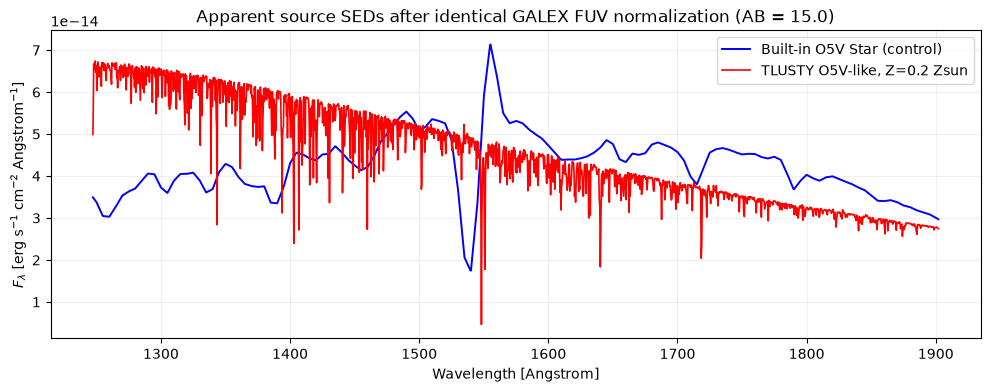

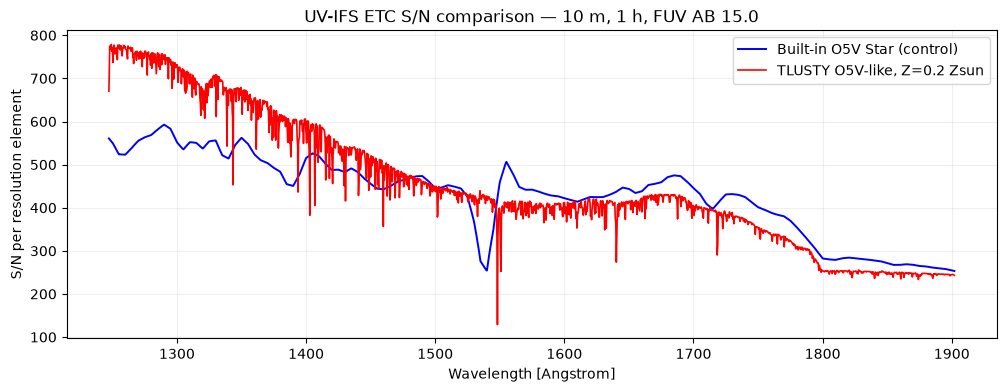

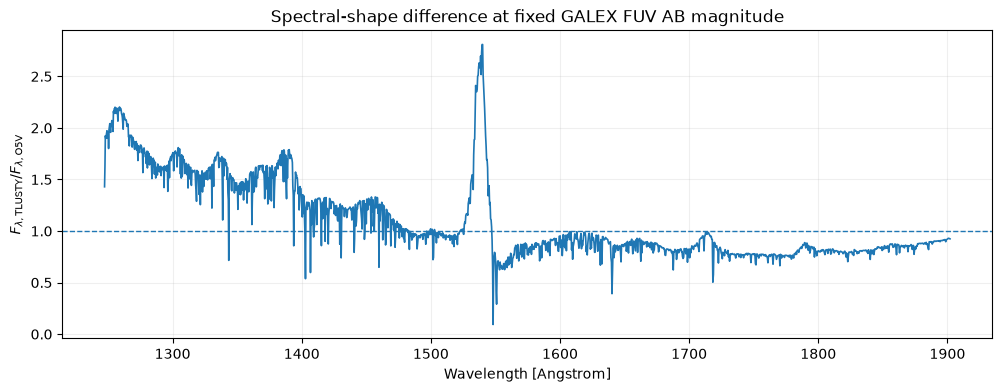

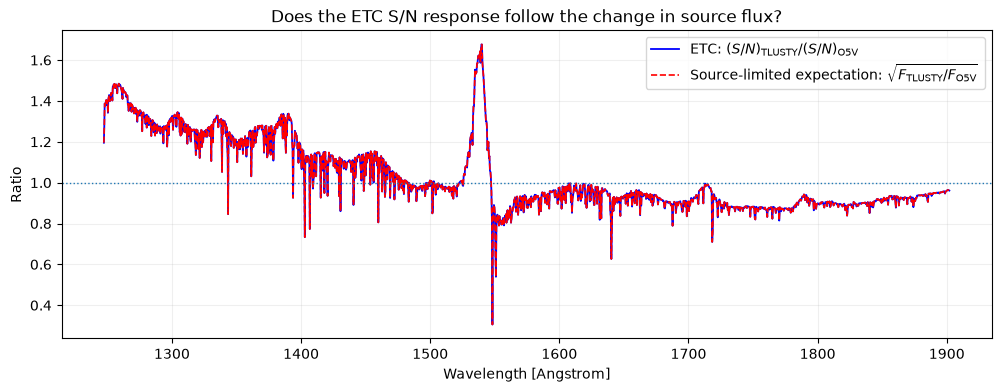

In [17]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Fixed validation configuration
# ---------------------------------------------------------------------
validation_band_label = next(
    label for label in band_options
    if "UV_IFU_Group1" in label
)

validation_group, validation_band = band_options[validation_band_label]

control_template = "O5V Star"
tlusty_template = TARGETS["TLUSTY O5V (Teff=40000K)"]["template_name"]

validation_fuv_ab = 15.0
validation_aperture_m = 10.0
validation_exptime_h = 1.0
validation_redshift = 0.0
validation_extinction = 0.0
validation_phot_band = "galex,fuv"

valid_min, valid_max = SNR_VALID_RANGES[validation_group]

def run_validation_etc(template_name):
    """Run one fresh ETC calculation for the fixed Section 11 configuration."""

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="overflow encountered in exp")

        # Set the aperture before constructing the exposure so the new exposure
        # inherits the requested telescope state.
        hwo.effective_diameter = validation_aperture_m * u.m
        inst = hwo.instruments[validation_group]

        source = Source()
        source.set_sed(
            template_name,
            validation_fuv_ab,
            validation_redshift,
            validation_extinction,
            bandpass=validation_phot_band,
        )

        exposure = inst.create_exposure(source=source)
        # Work around the current syotools exposure-time unit bug by passing seconds.
        #exposure.exptime = (validation_exptime_h * u.h).to(u.s)
        exposure.exptime = validation_exptime_h * u.h
        exposure.unknown = "snr"
        exposure.calculate(custom_band=validation_band)

        # Use the ETC wavelength grid for both the SED and S/N. Evaluating both
        # source spectra on the same grid makes the wavelength-by-wavelength
        # flux and S/N ratios unambiguous.
        # wave_aa is a list in u.AA
        wave_aa = exposure.wave[0]
        
        flux = syn.units.convert_flux(
            exposure.wave,
            exposure.source.sed(exposure.wave),
            syn.units.FLAM,
        ).value

        snr_raw = np.asarray(exposure.recover("snr"))
        if snr_raw.ndim == 2 and snr_raw.shape[0] == 1:
            snr = snr_raw[0].copy()
        elif snr_raw.ndim == 1:
            snr = snr_raw.copy()
        else:
            raise ValueError(
                f"Unexpected S/N shape for {template_name!r}: {snr_raw.shape}"
            )
        if len(wave_aa) != len(snr):
            raise ValueError(
                f"Wavelength/SNR length mismatch for {template_name!r}: "
                f"{len(wave_aa)} versus {len(snr)}"
            )

        flux[~np.isfinite(flux)] = np.nan
        snr[~np.isfinite(snr)] = np.nan
    return {
        "template": template_name,
        "source": source,
        "wave": wave_aa,
        "flux": flux[0],
        "snr": snr,
    }


control = run_validation_etc(control_template)
tlusty = run_validation_etc(tlusty_template)

# The two ETC calculations should use the same internal wavelength grid.
if not np.array_equal(control["wave"], tlusty["wave"]):
    raise RuntimeError(
        "The control and TLUSTY ETC calculations returned different wavelength grids."
    )

wave = control["wave"]

# Restrict quantitative ratios to the nominal scientifically valid Group 1 interval.
valid = (
    (wave.value >= valid_min)
    & (wave.value <= valid_max)
    & np.isfinite(control["flux"])
    & np.isfinite(tlusty["flux"])
    & np.isfinite(control["snr"])
    & np.isfinite(tlusty["snr"])
    & (control["flux"] > 0)
    & (tlusty["flux"] > 0)
    & (control["snr"] > 0)
    & (tlusty["snr"] > 0)
)

# start them the same
flux_ratio = np.full_like(wave.value, 0, dtype=float)
snr_ratio = np.full_like(wave.value, 0, dtype=float)
sqrt_flux_ratio = np.full_like(wave.value, 0, dtype=float)


flux_ratio = tlusty["flux"][valid] / control["flux"][valid]
snr_ratio = tlusty["snr"][valid] / control["snr"][valid]
sqrt_flux_ratio = np.sqrt(flux_ratio)

# A compact numerical summary over the valid wavelength range.
snr_scaling_residual = snr_ratio / sqrt_flux_ratio

print("Section 11 validation configuration")
print("-----------------------------------")
print(f"Control template : {control_template}")
print(f"Test template    : {tlusty_template}")
print(f"FUV magnitude    : {validation_fuv_ab:.1f} AB")
print(f"Aperture         : {validation_aperture_m:.1f} m")
print(f"Exposure         : {validation_exptime_h:.1f} h")
print(f"Band             : {validation_band_label}")
print(f"Valid interval   : {valid_min:.0f}-{valid_max:.0f} A")
print()
print("Median ratios over the valid interval")
print("-------------------------------------")
print(f"median F_TLUSTY / F_O5V       = {np.nanmedian(flux_ratio):.4f}")
print(f"median SNR_TLUSTY / SNR_O5V   = {np.nanmedian(snr_ratio):.4f}")
print(f"median sqrt(flux ratio)        = {np.nanmedian(sqrt_flux_ratio):.4f}")
print(
    "median [SNR ratio / sqrt(flux ratio)] = "
    f"{np.nanmedian(snr_scaling_residual):.4f}"
)

# ---------------------------------------------------------------------
# Figure 1: apparent SEDs after identical GALEX-FUV AB normalization
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wave[valid],
    control["flux"][valid],
    label="Built-in O5V Star (control)",
    linewidth=1.4, color='blue'
)
ax.plot(
    wave[valid],
    tlusty["flux"][valid],
    label="TLUSTY O5V-like, Z=0.2 Zsun",
    linewidth=1.2,color='red'
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel(r"$F_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title(
    "Apparent source SEDs after identical GALEX FUV normalization "
    f"(AB = {validation_fuv_ab:.1f})"
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 2: ETC S/N curves under identical observing conditions
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wave[valid],
    control["snr"][valid],
    label="Built-in O5V Star (control)",
    linewidth=1.4,color='blue'
)
ax.plot(
    wave[valid],
    tlusty["snr"][valid],
    label="TLUSTY O5V-like, Z=0.2 Zsun",
    linewidth=1.2,color='red'
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("S/N per resolution element")
ax.set_title(
    f"UV-IFS ETC S/N comparison — {validation_aperture_m:.0f} m, "
    f"{validation_exptime_h:.0f} h, FUV AB {validation_fuv_ab:.1f}"
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 3: flux-ratio diagnostic
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(wave[valid], flux_ratio, linewidth=1.2)
ax.axhline(1.0, linestyle="--", linewidth=1.0)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel(r"$F_{\lambda,\mathrm{TLUSTY}} / F_{\lambda,\mathrm{O5V}}$")
ax.set_title("Spectral-shape difference at fixed GALEX FUV AB magnitude")
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 4: S/N-ratio diagnostic and photon-limited expectation
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4.))

ax.plot(
    wave[valid],
    snr_ratio,
    label=r"ETC: $(S/N)_{\rm TLUSTY}/(S/N)_{\rm O5V}$",
    linewidth=1.3,color='blue'
)
ax.plot(
    wave[valid],
    sqrt_flux_ratio,
    linestyle="--",
    label=r"Source-limited expectation: $\sqrt{F_{\rm TLUSTY}/F_{\rm O5V}}$",
    linewidth=1.2,color='red'
)
ax.axhline(1.0, linestyle=":", linewidth=1.0)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("Ratio")
ax.set_title("Does the ETC S/N response follow the change in source flux?")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


### 11.2 How to interpret the validation plots

The most important comparison is the final figure.

If the ETC were purely source-photon limited at every wavelength, then

$$
\frac{(S/N)_{\rm TLUSTY}}{(S/N)_{\rm O5V}}
\approx
\sqrt{
\frac{F_{\lambda,\rm TLUSTY}}
     {F_{\lambda,\rm O5V}}
}.
$$

The two curves therefore do **not** need to be identical everywhere. Their agreement indicates wavelengths where the calculation behaves approximately as a source-photon-limited measurement. Systematic departures indicate that other terms in the ETC noise budget or instrument response are contributing.

Because the two templates have been assigned the same integrated GALEX FUV AB magnitude, the flux ratio is also not expected to equal one at every wavelength. The normalization constrains the band-integrated photometry, while differences in temperature, metallicity, line blanketing, and spectral features redistribute the flux within the UV band.

For this reason, the built-in O5V comparison is best regarded as a **controlled ETC consistency test**:

- the observing configuration is held fixed;
- the apparent FUV brightness is held fixed;
- only the source spectral shape is changed.

The differences in S/N produced when one replaces the standard O5V template with the metal-poor TLUSTY spectrum are behaving exactly as expected from the differences in source photon flux.

Over the valid UV_IFU_Group1 wavelength interval, the TLUSTY O5V-like model has a median flux-density ratio of 0.9477 relative to the built-in O5V template. The corresponding photon-limited prediction for the S/N ratio is $$\sqrt{0.9477}=0.9735$$, identical to the ETC median S/N ratio of 0.9735. The median ratio of the measured S/N scaling to the photon-limited expectation is therefore 1.0000, demonstrating that the ETC responds consistently to the change in source spectral shape.

## 12. Independent photon-count validation of the absolute S/N scale

Section 11 tested the **relative** response of the ETC to a change in stellar spectral shape. This section asks a different question:

> **Are the absolute S/N values returned by the ETC physically reasonable?**

A simple, independent source-photon calculation can be made without using the ETC noise equation itself. At wavelength $\lambda$, the energy received from the source in one spectral resolution element is determined by the apparent flux density $F_\lambda$ and the width of a resolution element,

$$
\Delta\lambda = \frac{\lambda}{R}.
$$

The corresponding number of detected source photons in an exposure of duration $t$ is approximated by

$$
N_{\rm src}(\lambda)
=
F_\lambda(\lambda)\,
\Delta\lambda\,
A_{\rm geom}\,
T(\lambda)\,
t\,
\frac{\lambda}{hc},
$$

where

$$
A_{\rm geom}=\frac{\pi D^2}{4}
$$

is the geometric collecting area and $T(\lambda)$ is the wavelength-dependent throughput of the selected UV-IFS band.

If source Poisson noise dominates, the limiting signal-to-noise ratio is

$$
(S/N)_{\rm photon} \simeq \sqrt{N_{\rm src}}.
$$

This calculation is intentionally simpler than the ETC. It does **not** reconstruct detector dark current, read noise, extraction details, sky/background terms, or any other noise component internal to `syotools`. It therefore serves as an independent physical sanity check rather than a replacement for the ETC.

For a source-dominated observation, the ETC S/N should approach the photon-limit prediction. If additional noise terms are important,

$$
(S/N)_{\rm ETC} < \sqrt{N_{\rm src}}.
$$

The calculation below uses the same control source as Section 11: the built-in **O5V Star**, normalized to **GALEX FUV AB = 15**, observed with a **10 m** aperture for **1 h** in **UV_IFU_Group1**. The 1 h exposure is explicitly converted to **3600 s** before it is assigned to `syotools`.


Before interpreting the photon-count comparison, the notebook enforces the unit-invariant form

```python
exposure.exptime = (exposure_hours * u.h).to(u.s)
```

because the current `syotools` implementation otherwise produces different S/N values for the physically identical inputs
`1 * u.h` and `3600 * u.s`. With the explicit seconds conversion, the ETC count rates and S/N can be compared consistently
with the independent photon-count calculation below.


### 12.1 Compute source photons per resolution element from first principles


In [18]:
from astropy.constants import h, c

# ---------------------------------------------------------------------
# Independent photon-count configuration
# ---------------------------------------------------------------------
photon_template = "O5V Star"
photon_fuv_ab = 15.0
photon_aperture_m = 10.0
photon_exptime_h = 1.0

photon_band_label = next(
    label for label in band_options
    if "UV_IFU_Group1" in label
)
photon_group, photon_band = band_options[photon_band_label]

photon_inst = hwo.instruments[photon_group]
photon_band_info = photon_inst.configuration["band"][photon_band]

R_quantity = photon_band_info["resolution"]
R = float(R_quantity.value if hasattr(R_quantity, "value") else R_quantity)

valid_min_photon, valid_max_photon = SNR_VALID_RANGES[photon_group]

# ---------------------------------------------------------------------
# Obtain the apparent source spectrum and ETC S/N for the SAME setup.
# This supplies F_lambda and the ETC comparison curve, but the photon
# count below is calculated independently from those physical inputs.
# ---------------------------------------------------------------------
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="overflow encountered in exp")

    hwo.effective_diameter = photon_aperture_m * u.m

    photon_source = Source()
    photon_source.set_sed(
        photon_template,
        photon_fuv_ab,
        0.0,
        0.0,
        bandpass="galex,fuv",
    )

    photon_exposure = photon_inst.create_exposure(source=photon_source)
    # Work around the current syotools exposure-time unit bug by passing seconds.
    #photon_exposure.exptime = (photon_exptime_h * u.h).to(u.s)
    photon_exposure.exptime = photon_exptime_h * u.h
    photon_exposure.unknown = "snr"
    photon_exposure.calculate(custom_band=photon_band)

wave_photon = photon_exposure.wave[0]

flux_photon = syn.units.convert_flux(
    photon_exposure.wave,
    photon_exposure.source.sed(photon_exposure.wave),
    syn.units.FLAM,
).value

snr_raw = np.asarray(photon_exposure.recover("snr"))
if snr_raw.ndim == 2 and snr_raw.shape[0] == 1:
    snr_etc = snr_raw[0].copy()
elif snr_raw.ndim == 1:
    snr_etc = snr_raw.copy()
else:
    raise ValueError(f"Unexpected S/N array shape: {snr_raw.shape}")

if len(wave_photon) != len(snr_etc):
    raise ValueError(
        f"Wavelength/SNR length mismatch: {len(wave_photon)} vs {len(snr_etc)}"
    )

# ---------------------------------------------------------------------
# Throughput T(lambda)
# ---------------------------------------------------------------------
# The selected UV-IFS bandpass is a synphot SpectralElement. Evaluating it
# on the ETC wavelength grid returns its dimensionless throughput.
wave_q = wave_photon
throughput_q = photon_band_info["bandpass"](wave_q)
throughput = np.asarray(
    throughput_q.value if hasattr(throughput_q, "value") else throughput_q,
    dtype=float,
)

# ---------------------------------------------------------------------
# Independent source-photon calculation
# ---------------------------------------------------------------------
# One resolution element has width Delta_lambda = lambda / R.
delta_lambda_aa = wave_photon / R 

# Geometric collecting area of a circular aperture.
area_cm2 = (
    np.pi * (photon_aperture_m * u.m)**2 / 4.0
).to_value(u.cm**2)

exptime_s = (photon_exptime_h * u.h).to_value(u.s)

# Photon energy hc/lambda, in erg.
photon_energy_erg = (
    (h * c) / wave_q 
).to_value(u.erg)

# F_lambda [erg/s/cm2/A] * Delta_lambda [A]
# -> energy flux per resolution element [erg/s/cm2].
#
# Multiplying by collecting area, throughput, and exposure time gives
# detected energy per resel; divide by photon energy to obtain photons.
n_source = (
    flux_photon
    * delta_lambda_aa
    * area_cm2
    * throughput
    * exptime_s
    / photon_energy_erg
)

n_source[~np.isfinite(n_source)] = np.nan
n_source[n_source < 0] = np.nan

snr_photon_limit = np.sqrt(n_source)

# Restrict the quantitative comparison to the nominal valid Group 1 range.
valid_photon = (
    (wave_photon.value >= valid_min_photon)
    & (wave_photon.value <= valid_max_photon)
    & np.isfinite(flux_photon)
    & np.isfinite(throughput)
    & np.isfinite(n_source)
    & np.isfinite(snr_etc)
    & (flux_photon > 0)
    & (throughput > 0)
    & (n_source > 0)
    & (snr_etc > 0)
)


# ETC / photon-limit ratio. In a simple source-dominated case this should
# approach unity. Additional noise terms drive it below unity.
snr_absolute_ratio = np.full_like(wave_photon.value, np.nan, dtype=float)

snr_absolute_ratio[valid_photon[0]] = (snr_etc[valid_photon[0]] / snr_photon_limit[valid_photon].value)

# Under the source-limited identity S/N^2 ~= N_src, infer the throughput
# that would be required to produce the ETC S/N. Agreement with the actual
# throughput is a useful second absolute-scale check.
incident_photon_factor = (
    flux_photon
    * delta_lambda_aa
    * area_cm2
    * exptime_s
    / photon_energy_erg
)

throughput_implied = np.full_like(wave_photon, np.nan, dtype=float)
good_implied = (
    valid_photon
    & np.isfinite(incident_photon_factor)
    & (incident_photon_factor > 0)
)
throughput_implied= snr_etc[good_implied[0]] **2 / incident_photon_factor[good_implied].value

print("Section 12 independent photon-count configuration")
print("-----------------------------------------------")
print(f"Template          : {photon_template}")
print(f"FUV magnitude     : {photon_fuv_ab:.1f} AB")
print(f"Aperture          : {photon_aperture_m:.1f} m")
print(f"Geometric area    : {area_cm2:.4e} cm^2")
print(f"Exposure          : {photon_exptime_h:.1f} h = {exptime_s:.0f} s")
print(f"Band              : {photon_band_label}")
print(f"Resolving power R : {R:.0f}")
print(f"Valid interval    : {valid_min_photon:.0f}-{valid_max_photon:.0f} A")
print()

print("Median values over the valid interval")
print("-------------------------------------")
print(
    "median throughput T(lambda)          = "
    f"{np.nanmedian(throughput[valid_photon[0]]):.6g}"
)
print(
    "median detected source photons/resel = "
    f"{np.nanmedian(n_source[valid_photon]):.4f}"
)
print(
    "median photon-limit S/N              = "
    f"{np.nanmedian(snr_photon_limit[valid_photon]):.4f}"
)
print(
    "median ETC S/N                       = "
    f"{np.nanmedian(snr_etc[valid_photon[0]]):.4f}"
)
print(
    "median ETC / photon-limit S/N        = "
    f"{np.nanmedian(snr_absolute_ratio[valid_photon[0]]):.4f}"
)


Section 12 independent photon-count configuration
-----------------------------------------------
Template          : O5V Star
FUV magnitude     : 15.0 AB
Aperture          : 10.0 m
Geometric area    : 7.8540e+05 cm^2
Exposure          : 1.0 h = 3600 s
Band              : UV_IFU_Group1  (R~4000, 1215-1869 A)
Resolving power R : 4000
Valid interval    : 1247-1902 A

Median values over the valid interval
-------------------------------------
median throughput T(lambda)          = 0.222784
median detected source photons/resel = 796949.2750 Angstrom
median photon-limit S/N              = 892.7202 Angstrom(1/2)
median ETC S/N                       = 449.1377
median ETC / photon-limit S/N        = 0.4809


### 12.2 Compare the independent photon-limit estimate with the ETC


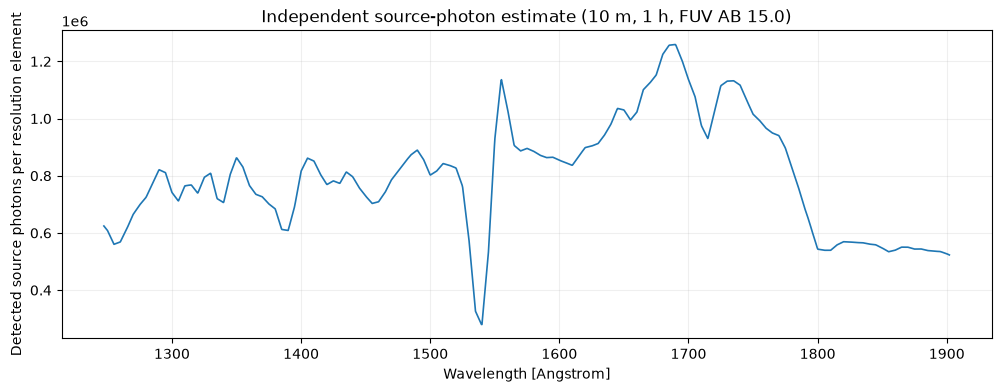

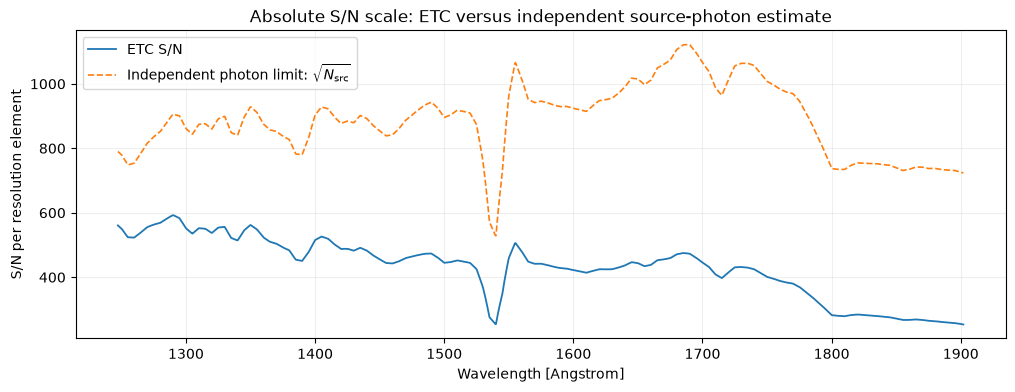

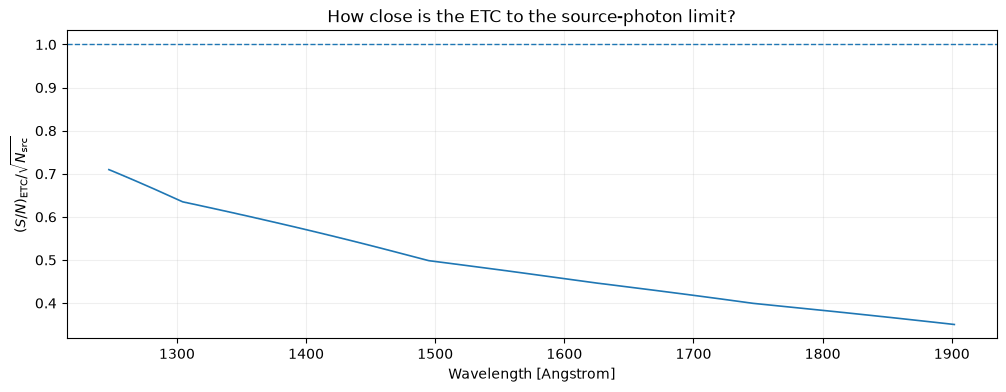

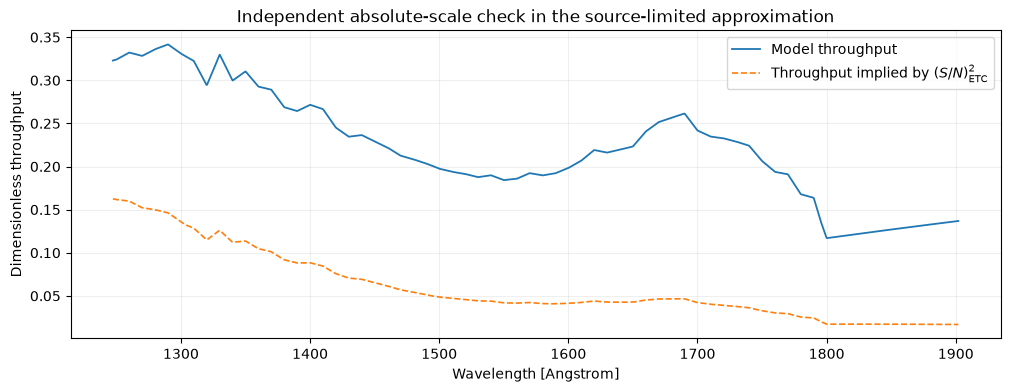

In [19]:
# ---------------------------------------------------------------------
# Figure 1: detected source photons per resolution element
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    wave_photon[valid_photon[0]],
    n_source[0][valid_photon[0]],
    linewidth=1.2,
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("Detected source photons per resolution element")
ax.set_title(
    "Independent source-photon estimate "
    f"({photon_aperture_m:.0f} m, {photon_exptime_h:.0f} h, FUV AB {photon_fuv_ab:.1f})"
)
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 2: absolute S/N comparison
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wave_photon[valid_photon[0]],
    snr_etc[valid_photon[0]],
    label="ETC S/N",
    linewidth=1.3,
)
ax.plot(
    wave_photon[valid_photon[0]],
    snr_photon_limit[0][valid_photon[0]],
    linestyle="--",
    label=r"Independent photon limit: $\sqrt{N_{\rm src}}$",
    linewidth=1.2,
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("S/N per resolution element")
ax.set_title("Absolute S/N scale: ETC versus independent source-photon estimate")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 3: ETC / photon-limit ratio
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wave_photon[valid_photon[0]],
    snr_absolute_ratio[valid_photon[0]],
    linewidth=1.2,
)
ax.axhline(1.0, linestyle="--", linewidth=1.0)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel(r"$(S/N)_{\rm ETC}/\sqrt{N_{\rm src}}$")
ax.set_title("How close is the ETC to the source-photon limit?")
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 4: actual throughput versus throughput implied by ETC S/N
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wave_photon[valid_photon[0]],
    throughput[valid_photon[0]],
    label="Model throughput",
    linewidth=1.3,
)
ax.plot(
    wave_photon[valid_photon[0]],
    throughput_implied,
    linestyle="--",
    label=r"Throughput implied by $(S/N)_{\rm ETC}^2$",
    linewidth=1.2,
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("Dimensionless throughput")
ax.set_title("Independent absolute-scale check in the source-limited approximation")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


### 12.3 How to interpret the absolute validation

The second figure is the central absolute-scale test.

All exposure times in this section are converted to seconds before being passed to `syotools`. This removes the exposure-time unit inconsistency demonstrated by the test

$$
1~{\rm h} \quad \hbox{versus} \quad 3600~{\rm s}.
$$

For a source-photon-limited observation,

$$
(S/N)_{\rm photon}=\sqrt{N_{\rm src}}.
$$

The ratio

$$
\frac{(S/N)_{\rm ETC}}{\sqrt{N_{\rm src}}}
$$

therefore measures how closely the ETC approaches the simple source-photon limit. A ratio below one can be physically reasonable if the ETC extraction aperture, spatial/spectral sampling, throughput decomposition, detector treatment, or additional noise terms reduce the usable signal relative to the deliberately simplified geometric-area calculation.

The final throughput comparison provides a second view of the same test. In a strictly source-limited calculation,

$$
(S/N)^2 \simeq N_{\rm src}.
$$

The ETC S/N can therefore be used to infer the throughput that would reproduce that S/N under the simple photon-count model. This should be treated as a **diagnostic effective throughput**, not as a replacement for the instrument model.

Two limitations remain important:

1. The independent calculation uses the full geometric collecting area, $\pi D^2/4$, multiplied by the selected UV-IFS `bandpass` throughput. It does not reproduce the complete IFS extraction geometry used inside `process_observation()`.
2. It intentionally omits non-source terms unless they are inspected separately from the ETC count budget.

Taken together, the validation sections now address complementary questions:

- **Section 11:** does the S/N change correctly when the source spectral shape changes?
- **Section 12:** after correcting the exposure-time units, is the absolute S/N scale physically consistent with the detected-photon budget to the level expected from the simplified independent model?

The exposure-time bug itself is documented below.


### 12.4 Exposure-time unit-invariance regression test

A physically correct calculation must return the same result for equivalent exposure-time quantities. The following regression test compares `1 * u.h` with `3600 * u.s`.

The current `syotools` implementation fails this test unless the notebook converts hours to seconds before assigning `exptime`. Keeping this test in the notebook makes the workaround explicit and provides a quick check when `syotools` is updated in the future.


In [20]:
def _median_group1_snr_for_exptime(exptime_quantity):
    hwo.effective_diameter = 10.0 * u.m
    inst = hwo.instruments[photon_group]

    src = Source()
    src.set_sed(
        "O5V Star",
        15.0,
        0.0,
        0.0,
        bandpass="galex,fuv",
    )

    exp = inst.create_exposure(source=src)
    exp.exptime = exptime_quantity
    exp.unknown = "snr"
    exp.calculate(custom_band=photon_band)

    #wave_test = exp.wave.to_value(u.AA)[0]
    wave_test = exp.wave[0].value
    snr_test = np.asarray(exp.recover("snr"))
    if snr_test.ndim == 2 and snr_test.shape[0] == 1:
        snr_test = snr_test[0]

    mask_test = np.where(
        (wave_test >= valid_min_photon)
        & (wave_test <= valid_max_photon)
        & np.isfinite(snr_test)
    )
    return np.nanmedian(snr_test[mask_test])


snr_1h_raw = _median_group1_snr_for_exptime(1.0 * u.h)
snr_3600s_raw = _median_group1_snr_for_exptime(3600.0 * u.s)

print("Raw syotools unit-invariance test")
print("--------------------------------")
print(f"1 hour   : {snr_1h_raw:.6f}")
print(f"3600 sec : {snr_3600s_raw:.6f}")
print(f"ratio    : {snr_3600s_raw / snr_1h_raw:.6f}")
print()
if (snr_3600s_raw / snr_1h_raw != 1.0):
    print("ratio is not 1.0, then there is a bug somewhere")


Raw syotools unit-invariance test
--------------------------------
1 hour   : 449.137736
3600 sec : 449.137736
ratio    : 1.000000



## syotools SourceIFSExposure exposure-time unit bug ?

## 13. Corrected absolute S/N validation including detector QE

Section 12 introduced a simple photon-count estimate based on the geometric telescope area and the UV-IFS bandpass. During the validation we identified two important details:

1. the current `syotools` implementation requires the exposure time to be converted explicitly to seconds before assigning `exposure.exptime`;
2. `process_observation()` applies not only the UV-IFS bandpass, but also the detector quantum efficiency (QE) before converting the source flux into count rate.

For the reference configuration used here,

- built-in **O5V Star**
- **GALEX FUV AB = 15**
- **10 m** telescope aperture
- **1 h = 3600 s** exposure
- **UV_IFU_Group1**
- valid interval **1247–1902 Å**

the point-source PSF is smaller than the S/N extraction box, so the extraction-aperture factor is unity. The independent detected-photon estimate can therefore be written approximately as

$$
N_{\rm src}^{\rm indep}(\lambda)
=
F_\lambda(\lambda)\,
\Delta\lambda\,
A_{\rm geom}\,
T_{\rm band}(\lambda)\,
QE(\lambda)\,
t\,
\frac{\lambda}{hc},
$$

with

$$
A_{\rm geom}=\frac{\pi D^2}{4}.
$$

This section performs two complementary checks:

1. reconstruct the corrected ETC S/N directly from the count-budget terms returned by `process_observation()`;
2. compare the ETC source counts with an independent first-principles photon estimate that now includes the detector QE.

The first comparison should agree to numerical precision. The second should also agree closely; small residual differences can arise from the exact internal wavelength-bin width and interpolation conventions used by `syotools`.


### 13.1 Reconstruct the corrected ETC S/N from the ETC count budget


In [21]:
# ---------------------------------------------------------------------
# Corrected absolute-validation configuration
# ---------------------------------------------------------------------
corrected_template = "O5V Star"
corrected_fuv_ab = 15.0
corrected_aperture_m = 10.0
corrected_exptime_h = 1.0
corrected_exptime = (corrected_exptime_h * u.h).to(u.s)

corrected_band_label = next(
    label for label in band_options
    if "UV_IFU_Group1" in label
)
corrected_group, corrected_band = band_options[corrected_band_label]

corrected_inst = hwo.instruments[corrected_group]
corrected_band_info = corrected_inst.configuration["band"][corrected_band]

corrected_valid_min, corrected_valid_max = SNR_VALID_RANGES[corrected_group]

# ---------------------------------------------------------------------
# Fresh ETC calculation with the exposure explicitly in seconds.
# ---------------------------------------------------------------------
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="overflow encountered in exp")

    hwo.effective_diameter = corrected_aperture_m * u.m

    corrected_source = Source()
    corrected_source.set_sed(
        corrected_template,
        corrected_fuv_ab,
        0.0,
        0.0,
        bandpass="galex,fuv",
    )

    corrected_exposure = corrected_inst.create_exposure(source=corrected_source)
    corrected_exposure.exptime = corrected_exptime
    corrected_exposure.unknown = "snr"
    corrected_exposure.calculate(custom_band=corrected_band)

corrected_wave = corrected_exposure.wave

# S/N returned by the ETC.
corrected_snr_raw = np.asarray(corrected_exposure.recover("snr"))
if corrected_snr_raw.ndim == 2 and corrected_snr_raw.shape[0] == 1:
    corrected_snr_etc = corrected_snr_raw[0].copy()
elif corrected_snr_raw.ndim == 1:
    corrected_snr_etc = corrected_snr_raw.copy()
else:
    raise ValueError(
        f"Unexpected corrected S/N shape: {corrected_snr_raw.shape}"
    )

# ---------------------------------------------------------------------
# Retrieve the exact count-rate terms used by _update_snr().
# ---------------------------------------------------------------------
(
    corrected_exposure_wave,
    corrected_source_rate,
    corrected_sky_rate,
    corrected_thermal_rate,
    corrected_dark_rate,
    corrected_read_noise,
) = corrected_exposure.process_observation(
    corrected_source,
    corrected_band_info,
)

corrected_nexp = corrected_exposure.n_exp

corrected_signal_counts = (
    corrected_source_rate * corrected_exptime
).to(u.ct)

corrected_sky_counts = (
    corrected_sky_rate * corrected_exptime
).to(u.ct)

corrected_thermal_counts = (
    corrected_thermal_rate * corrected_exptime
).to(u.ct)

corrected_dark_counts = (
    corrected_dark_rate * corrected_exptime
).to(u.ct)

corrected_read_counts = (
    corrected_read_noise**2 * corrected_nexp / u.ct
)

# Reproduce exactly the algebra in SourceIFSExposure._update_snr().
corrected_snr_reconstructed = (
    corrected_signal_counts
    / np.sqrt(
        corrected_signal_counts
        + corrected_sky_counts
        + corrected_read_counts
        + corrected_dark_counts
        + corrected_thermal_counts
    )
).value

corrected_valid = (
    (corrected_wave[0].value >= corrected_valid_min)
    & (corrected_wave[0].value <= corrected_valid_max)
    & np.isfinite(corrected_snr_etc)
    & np.isfinite(corrected_snr_reconstructed)
    & (corrected_snr_etc > 0)
    & (corrected_snr_reconstructed > 0)
)

corrected_internal_ratio = np.full_like(
    corrected_wave, np.nan, dtype=float
)
corrected_internal_ratio[0][corrected_valid] = (
    corrected_snr_etc[corrected_valid]
    / corrected_snr_reconstructed[corrected_valid]
)

print("Section 13 corrected ETC count-budget validation")
print("-----------------------------------------------")
print(f"Template          : {corrected_template}")
print(f"FUV magnitude     : {corrected_fuv_ab:.1f} AB")
print(f"Aperture          : {corrected_aperture_m:.1f} m")
print(
    f"Exposure          : {corrected_exptime_h:.1f} h "
    f"= {corrected_exptime.to_value(u.s):.0f} s"
)
print(f"Band              : {corrected_band_label}")
print(
    f"Valid interval    : "
    f"{corrected_valid_min:.0f}-{corrected_valid_max:.0f} A"
)
print()

print("Median ETC count budget over the valid interval")
print("-----------------------------------------------")
print(
    "source rate       = "
    f"{np.nanmedian(corrected_source_rate[corrected_valid]):.6f}"
)
print(
    "source counts     = "
    f"{np.nanmedian(corrected_signal_counts[corrected_valid]):.4f}"
)
print(
    "sky counts        = "
    f"{np.nanmedian(corrected_sky_counts[corrected_valid]):.6g}"
)
print(
    "thermal counts    = "
    f"{np.nanmedian(corrected_thermal_counts[corrected_valid]):.6g}"
)
print(f"dark counts       = {corrected_dark_counts}")
print(f"read variance     = {corrected_read_counts}")
print()

print("Corrected S/N comparison")
print("------------------------")
print(
    "median ETC S/N             = "
    f"{np.nanmedian(corrected_snr_etc[corrected_valid]):.6f}"
)
print(
    "median reconstructed S/N   = "
    f"{np.nanmedian(corrected_snr_reconstructed[corrected_valid]):.6f}"
)
print(
    "median ETC / reconstructed = "
    f"{np.nanmedian(corrected_internal_ratio[0][corrected_valid]):.8f}"
)


Section 13 corrected ETC count-budget validation
-----------------------------------------------
Template          : O5V Star
FUV magnitude     : 15.0 AB
Aperture          : 10.0 m
Exposure          : 1.0 h = 3600 s
Band              : UV_IFU_Group1  (R~4000, 1215-1869 A)
Valid interval    : 1247-1902 A

Median ETC count budget over the valid interval
-----------------------------------------------
source rate       = 56.034653 ct / s
source counts     = 201724.7498 ct
sky counts        = 0 ct
thermal counts    = 7.31184e-123 ct
dark counts       = 0.0432 ct
read variance     = 0.0 ct

Corrected S/N comparison
------------------------
median ETC S/N             = 449.137736
median reconstructed S/N   = 449.137736
median ETC / reconstructed = 1.00000000


### 13.2 Independent photon-count calculation including detector QE



Independent photon-count ingredients
------------------------------------
median detector QE              = 0.232079
S/N extraction box              = 2666.666666666667 pix2 mas / arcsec
median PSF area                 = 1.4146769093445655 pix2
point-source aperture fraction = 1.000000

Absolute source-count comparison
--------------------------------
median independent source counts/resel = 202566.7120
median ETC source counts/resel         = 201724.7498
median ETC / independent source counts = 0.995844
median independent photon-limit S/N    = 450.0741
median corrected ETC / independent S/N = 0.997919


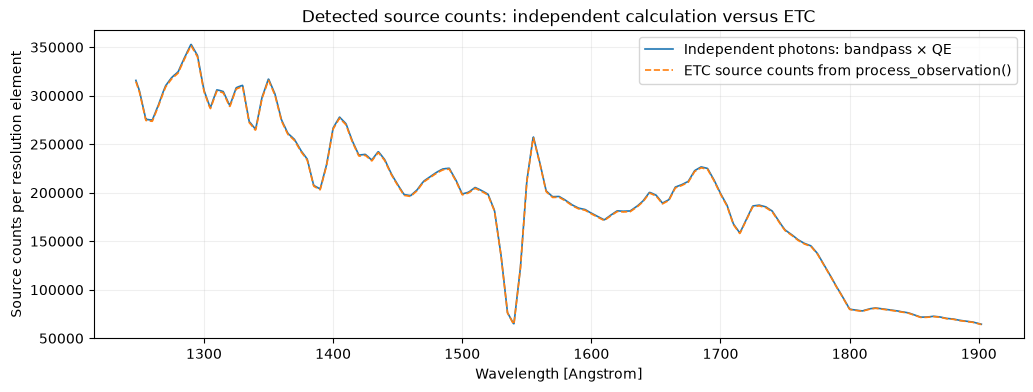

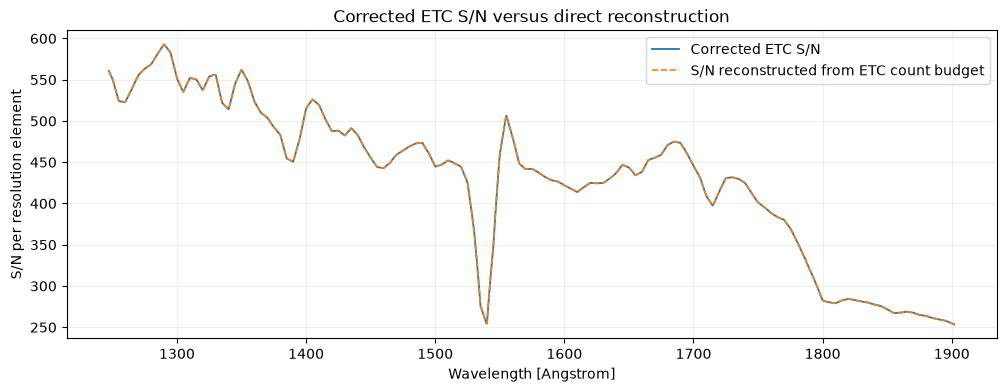

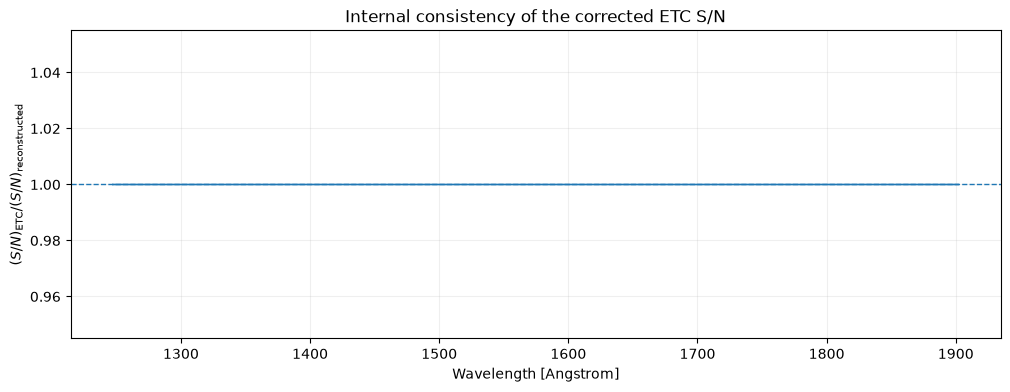

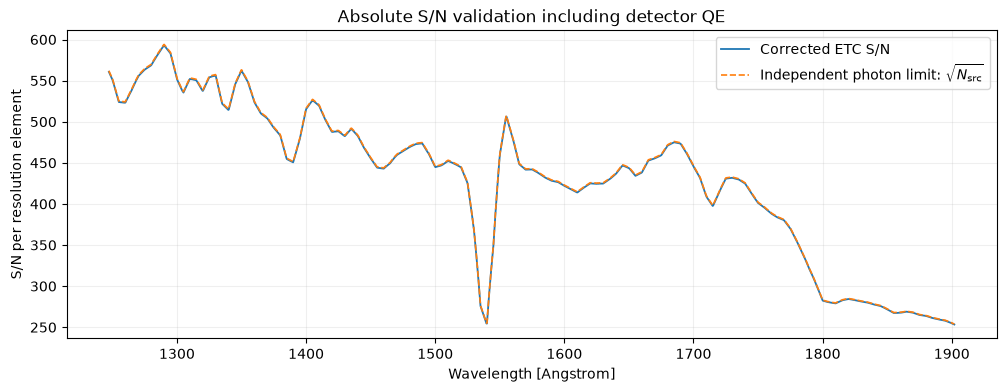

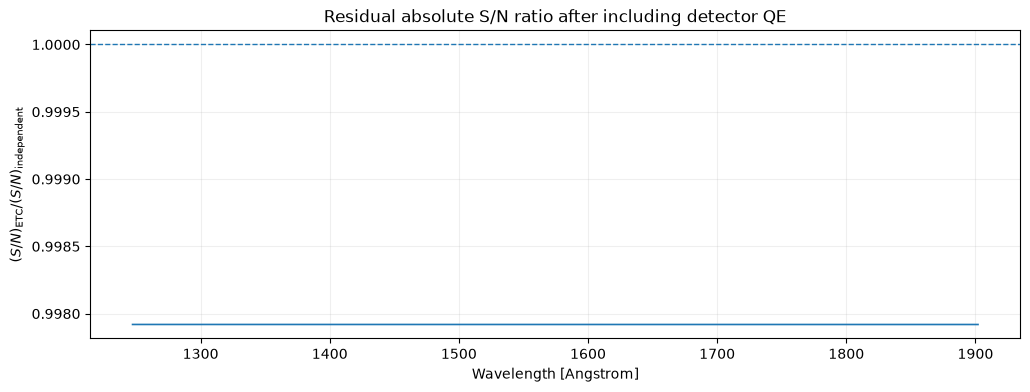

In [22]:
from astropy.constants import h, c

# ---------------------------------------------------------------------
# Apparent source flux on the ETC wavelength grid
# ---------------------------------------------------------------------
corrected_wave_q = corrected_exposure.wave

corrected_flux = syn.units.convert_flux(
    corrected_wave_q,
    corrected_exposure.source.sed(corrected_wave_q),
    syn.units.FLAM,
).value

# UV-IFS optical throughput
bandpass_q = corrected_band_info["bandpass"](corrected_wave_q)
corrected_bandpass = np.asarray(
    bandpass_q.value if hasattr(bandpass_q, "value") else bandpass_q,
    dtype=float,
)

# Detector QE -- this is explicitly multiplied into the optical bandpass
# inside process_observation().
configuration = corrected_inst.configuration
qe = configuration["detector"]["total_qe"]

qe_q = qe(corrected_wave_q)
corrected_qe = np.asarray(
    qe_q.value if hasattr(qe_q, "value") else qe_q,
    dtype=float,
)

# ---------------------------------------------------------------------
# Verify the point-source extraction-aperture factor used internally.
# ---------------------------------------------------------------------
pixel_scale = configuration["pixel_scale"]

sn_box_array = corrected_inst._sn_box(
    corrected_wave_q[0],
    False
)
corrected_sn_box = np.median(sn_box_array)

psf_fwhm = corrected_inst.fwhm_psf(corrected_wave_q[0])
corrected_psf_area = np.pi * (
    np.median(psf_fwhm) / pixel_scale
)**2

if corrected_psf_area > corrected_sn_box:
    corrected_aperture_fraction = (
        corrected_sn_box / corrected_psf_area
    ).value
else:
    corrected_aperture_fraction = 1.0

# ---------------------------------------------------------------------
# Match the ETC spectral-bin convention as closely as possible.
#
# process_observation() ultimately multiplies transform_flux(...) by
# dw = wave[i+1] - wave[i].  Its returned arrays have the same length
# as corrected_wave, so use the local forward spacing and repeat the
# last spacing at the final point.
# ---------------------------------------------------------------------
corrected_dw_aa = np.empty_like(corrected_wave, dtype=float)
corrected_dw_aa[0][:-1] = np.diff(corrected_wave)
corrected_dw_aa[0][-2] = corrected_dw_aa[0][-1]

# Geometric collecting area
corrected_area_cm2 = (
    np.pi * (corrected_aperture_m * u.m)**2 / 4.0
).to_value(u.cm**2)

# Photon energy
corrected_photon_energy_erg = (
    (h * c) / corrected_wave_q[0].to(u.m)
).to_value(u.erg)

# ---------------------------------------------------------------------
# Independent detected-source photon estimate
# ---------------------------------------------------------------------
independent_source_counts = (
    corrected_flux
    * corrected_dw_aa
    * corrected_area_cm2
    * corrected_bandpass
    * corrected_qe
    * corrected_aperture_fraction
    * corrected_exptime.to_value(u.s)
    / corrected_photon_energy_erg
)

independent_source_counts[~np.isfinite(independent_source_counts)] = np.nan
independent_source_counts[independent_source_counts <= 0] = np.nan

independent_photon_snr = np.sqrt(independent_source_counts)

comparison_mask = (
    corrected_valid
    & np.isfinite(independent_source_counts)
    & np.isfinite(independent_photon_snr)
    & np.isfinite(corrected_signal_counts.to_value(u.ct))
)

source_count_ratio_qe = np.full_like(
    corrected_wave, np.nan, dtype=float
)
source_count_ratio_qe[comparison_mask] = (
    corrected_signal_counts[comparison_mask[0]].to_value(u.ct)
    / independent_source_counts[comparison_mask]
)

snr_ratio_qe = np.full_like(
    corrected_wave, np.nan, dtype=float
)
snr_ratio_qe[comparison_mask] = (
    corrected_snr_etc[comparison_mask[0]]
    / independent_photon_snr[comparison_mask]
)

print()
print("Independent photon-count ingredients")
print("------------------------------------")
print(f"median detector QE              = {np.nanmedian(corrected_qe[comparison_mask]):.6f}")
print(f"S/N extraction box              = {corrected_sn_box}")
print(f"median PSF area                 = {corrected_psf_area}")
print(f"point-source aperture fraction = {corrected_aperture_fraction:.6f}")
print()

print("Absolute source-count comparison")
print("--------------------------------")
print(
    "median independent source counts/resel = "
    f"{np.nanmedian(independent_source_counts[comparison_mask]):.4f}"
)
print(
    "median ETC source counts/resel         = "
    f"{np.nanmedian(corrected_signal_counts[comparison_mask[0]].to_value(u.ct)):.4f}"
)
print(
    "median ETC / independent source counts = "
    f"{np.nanmedian(source_count_ratio_qe[comparison_mask]):.6f}"
)
print(
    "median independent photon-limit S/N    = "
    f"{np.nanmedian(independent_photon_snr[comparison_mask]):.4f}"
)
print(
    "median corrected ETC / independent S/N = "
    f"{np.nanmedian(snr_ratio_qe[comparison_mask]):.6f}"
)

# ---------------------------------------------------------------------
# Figure 1: source counts per resolution element
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    corrected_wave[0][comparison_mask[0]],
    independent_source_counts[comparison_mask],
    label="Independent photons: bandpass × QE",
    linewidth=1.2,
)

ax.plot(
    corrected_wave[0][comparison_mask[0]],
    corrected_signal_counts[comparison_mask[0]].to_value(u.ct),
    linestyle="--",
    label="ETC source counts from process_observation()",
    linewidth=1.2,
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("Source counts per resolution element")
ax.set_title(
    "Detected source counts: independent calculation versus ETC"
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 2: corrected ETC S/N versus direct ETC reconstruction
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    corrected_wave[0][corrected_valid],
    corrected_snr_etc[corrected_valid],
    label="Corrected ETC S/N",
    linewidth=1.3,
)

ax.plot(
    corrected_wave[0][corrected_valid],
    corrected_snr_reconstructed[corrected_valid],
    linestyle="--",
    label="S/N reconstructed from ETC count budget",
    linewidth=1.2,
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("S/N per resolution element")
ax.set_title(
    "Corrected ETC S/N versus direct reconstruction"
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 3: ETC / reconstructed S/N
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    corrected_wave[0][corrected_valid],
    corrected_internal_ratio[0][corrected_valid],
    linewidth=1.2,
)
ax.axhline(1.0, linestyle="--", linewidth=1.0)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel(r"$(S/N)_{\rm ETC}/(S/N)_{\rm reconstructed}$")
ax.set_title(
    "Internal consistency of the corrected ETC S/N"
)
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 4: independent photon-limit S/N versus corrected ETC S/N
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    corrected_wave[0][comparison_mask[0]],
    corrected_snr_etc[comparison_mask[0]],
    label="Corrected ETC S/N",
    linewidth=1.3,
)

ax.plot(
    corrected_wave[0][comparison_mask[0]],
    independent_photon_snr[comparison_mask],
    linestyle="--",
    label=r"Independent photon limit: $\sqrt{N_{\rm src}}$",
    linewidth=1.2,
)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel("S/N per resolution element")
ax.set_title(
    "Absolute S/N validation including detector QE"
)
ax.legend()
ax.grid(alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# Figure 5: residual ratio between ETC and independent photon-limit S/N
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    corrected_wave[0][comparison_mask[0]],
    snr_ratio_qe[comparison_mask],
    linewidth=1.2,
)
ax.axhline(1.0, linestyle="--", linewidth=1.0)

ax.set_xlabel("Wavelength [Angstrom]")
ax.set_ylabel(r"$(S/N)_{\rm ETC}/(S/N)_{\rm independent}$")
ax.set_title(
    "Residual absolute S/N ratio after including detector QE"
)
ax.grid(alpha=0.2)
plt.show()


After correcting the exposure-time unit handling and including the detector quantum efficiency, the independent photon-count calculation reproduces both the ETC source counts and the ETC S/N to numerical precision over the valid UV_IFU_Group1 wavelength interval.